# 10. 기상 x 매출: 업종그룹과 연령대로 쪼개 보기

## 이 노트북이 하는 일
05번은 날씨 효과를 **업종그룹별로 한 번**, **연령별로 한 번** 따로 봤다. 이 노트북은 두 축을 **동시에** 본다.
"비 오는 날 춘천 카페가 15% 빠진다"가 아니라 **"비 오는 날 춘천 카페의 어느 연령대가 빠지는가"** 까지 내려간다.

## 답해야 할 질문
1. 업종그룹 x 연령대 칸마다 폭염, 호우 효과는 얼마인가? 지도(히트맵)로 그리면 어떤 모양인가?
2. 그 차이가 **우연이 아닌가?** (칸마다 따로 돌린 140개 회귀는 우연히 유의한 칸을 만든다)
3. 충격 뒤 회복 속도도 연령마다 다른가? 늦게 돌아오는 칸은 어디인가?
4. 쪼갠 뒤에도 감소의 경로는 건수(안 옴)인가, 객단가(덜 씀)인가?
5. 데이터가 너무 성겨 뺀 **10대**는 따로 보면 무엇을 말하는가?

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 만든 노트북 | 출력 |
|---|---|---|
| `card1.parquet`, `calendar.parquet`, `industry_map.csv` | 01 | 그래프와 결과 표 (노트북 안) |
| `wx_region_daily.parquet`, `wx_events.parquet` | 04 | 저장하는 파일 없음 |

> 먼저 실행할 노트북: **01 -> 04 -> 05** 를 끝낸 뒤 이 노트북을 연다.
> 0-3의 설정값은 05번 0-3과 **똑같이** 맞춰 두었다. 05번에서 값을 바꿨으면 여기도 같이 바꾼다.

## 이 노트북의 규칙
- 코드는 모두 채워져 있다. 위에서 아래로 실행하면 된다.
- 회귀 계수는 로그 매출에 대한 값이라 **% 효과 = (exp(계수) - 1) x 100** 으로 바꿔 읽는다.
- **절대 금액은 쓰지 않는다.** 08번에서 확인한 대로 카드 금액과 건수에는 배수가 곱해져 있다. 비중과 % 변화만 쓴다.
- 칸을 잘게 쪼갤수록 숫자가 흔들린다. 그래서 3장(히트맵)은 **모양 보기**, 주장은 4장(상호작용 검정)으로만 한다.

## 결과 요약
1. **쪼개도 폭염은 없다.** 업종그룹 x 연령 140칸에서 폭염은 p < 0.05가 34칸 나오지만 **다중검정을 통과하는 칸이 0개** 다. 호우는 24칸이 통과하고 그중 22칸이 춘천이다.
2. **춘천 호우 효과는 연령에 따라 U자다.** 지역 합계로 10대 -14.1%, 20 ~ 40대 -5.6%, 50대 -10.7%, 60대 이상 -12.7%. 가운데가 가장 덜 빠지고 양 끝이 크게 빠진다. 강남은 모든 연령이 0 근처다.
3. **회복 속도도 연령마다 다르다.** 춘천에서 20 ~ 40대는 호우 다음 날 0으로 돌아오지만 **60대 이상은 +7일까지 음수에 머문다.** "하루 만에 회복한다"는 05번의 결론은 평균의 이야기였다.
4. **감소는 거의 전부 방문이다.** BH를 통과한 24칸에서 매출 감소 중 건수가 차지하는 몫의 중앙값이 95%다. 예외는 춘천 스포츠시설로, 큰 결제(객단가)가 통째로 사라진다.
5. **폭염은 총액이 아니라 구성을 바꾼다.** 수준 효과는 한 칸도 살아남지 않는데 연령 교차항은 28개 조합 중 10개에서 유의하다. 더운 날 누가 쓰는지가 바뀌는 것이다.

## 0. 준비

### 0-1. 라이브러리와 그래프 설정

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests   # 3-3의 다중검정 보정
from statsmodels.tools.sm_exceptions import SingularMatrixWarning

sns.set_theme(style='whitegrid')
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
plt.rc('figure', figsize=(12, 4), dpi=110)

REGIONS = ['강남', '춘천']
REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}
pd.set_option('display.float_format', '{:,.3f}'.format)

# 7장에서 기준선을 칸마다 따로 학습하는데, 추석 당일에 결제가 없던 칸은 그 더미가 전부 0이 된다.
# 계산은 정상이고 그 더미의 계수만 0으로 나오므로, 경고만 끄고 진행한다.
warnings.filterwarnings('ignore', category=SingularMatrixWarning)
print('준비 완료')

준비 완료


### 0-2. 경로와 데이터 불러오기

In [2]:
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

card1    = pd.read_parquet(OUT / 'card1.parquet')                # 01번: 날짜 x 시간대 x 지역 x 업종 x 성별 x 연령
calendar = pd.read_parquet(OUT / 'calendar.parquet')             # 01번: 날짜별 요일, 공휴일
wx       = pd.read_parquet(OUT / 'wx_region_daily.parquet')      # 04번: 날짜 x 지역 일별 날씨
events   = pd.read_parquet(OUT / 'wx_events.parquet')            # 04번: 폭염, 호우 연속 구간 목록

for name, df in [('card1', card1), ('calendar', calendar), ('wx', wx), ('events', events)]:
    print(f'{name:9s} {df.shape[0]:>9,}행 x {df.shape[1]:2d}열')

card1     1,663,909행 x 11열
calendar        184행 x  9열
wx              368행 x 20열
events           43행 x  7열


### 0-3. 05번에서 가져온 결정
05번 0-3, 2-4, 3-4, 6-3, 8-1에서 정한 값을 그대로 옮긴다. **05번에서 바꾸면 이 셀도 같이 바꾼다.**

| 변수 | 값 | 05번 어디서 |
|---|---|---|
| `CAL_FORMULA` | 요일 + 공휴일 + 월 + 추석 연휴 + 추석 3일 (월말은 뺌) | 2-4 결정 |
| `THRESH` | 폭염 33℃, 열대야 25℃, 호우 30mm | 3-4 결정 |
| `WINDOW` | (-3, 7) | 6-3 결정 |
| `RECOVERY_BAND` | 0.03 | 8-1 결정 |
| `AGE_GROUP` | 60대 이상을 하나로 | 02번 7-3 |
| `MAIN_AGES` | 분석에 쓸 연령 5개 (10대는 1장에서 뺌) | 이 노트북 1-3 |

In [3]:
CAL_FORMULA   = 'C(dow) + is_holiday + C(month) + is_chuseok_break + C(chuseok_day)'
THRESH        = {'heat': 33, 'tropical': 25, 'rain': 30}
WINDOW        = (-3, 7)
RECOVERY_BAND = 0.03

AGE_GROUP = {'10대': '10대', '20대': '20대', '30대': '30대', '40대': '40대', '50대': '50대',
             '60대': '60대 이상', '70대': '60대 이상', '80대': '60대 이상', '90대': '60대 이상'}
ALL_AGES  = ['10대', '20대', '30대', '40대', '50대', '60대 이상']
MAIN_AGES = ['20대', '30대', '40대', '50대', '60대 이상']   # 1-3에서 10대를 뺀 결과

PRIORITY_GROUPS = ['음식점', '카페', '편의점', '식료품']    # 02번 5-4
CAUTION_GROUPS  = ['주점/유흥', '여가/오락']               # 02번 2-3

WX_NAME = {'heat33': '폭염', 'tropical': '열대야', 'rain30': '호우'}
EV_NAME = {'heat33': '폭염', 'rain30': '호우'}
WX_VARS = ['heat33[T.True]', 'tropical[T.True]', 'rain30[T.True]']

for k, v in [('CAL_FORMULA', CAL_FORMULA), ('THRESH', THRESH), ('WINDOW', WINDOW),
             ('RECOVERY_BAND', RECOVERY_BAND), ('MAIN_AGES', MAIN_AGES)]:
    print(f'{k:16s} = {v}')

CAL_FORMULA      = C(dow) + is_holiday + C(month) + is_chuseok_break + C(chuseok_day)
THRESH           = {'heat': 33, 'tropical': 25, 'rain': 30}
WINDOW           = (-3, 7)
RECOVERY_BAND    = 0.03
MAIN_AGES        = ['20대', '30대', '40대', '50대', '60대 이상']


### 0-4. 분석 기본 표
05번 0-4와 똑같이 처리한다. 개인 결제만 남기고, 추석 3일을 따로 표시하고, 추석 당일에 걸린 호우 표시(강남 10/6)를 끈다.

In [4]:
# 1) 분석 대상 행만 (법인 제외)
base1 = card1[card1['is_target'] & card1['sex'].ne('법인')].copy()
base1['age_g'] = base1['age'].map(AGE_GROUP)
print(f'base1 {len(base1):,}행')

# 2) 추석 3일 열
CORE = {pd.Timestamp('2025-10-05'): 1, pd.Timestamp('2025-10-06'): 2, pd.Timestamp('2025-10-07'): 3}
calendar['chuseok_day'] = calendar['date'].map(CORE).fillna(0).astype(int)

# 3) 추석 3일에 걸린 호우 표시 끄기 (강남 10/6. 05번 2-4에서 이유 확인)
wx.loc[wx['date'].isin(CORE), 'rain30'] = False
events = events[~(events['event'].eq('rain30') & events['start'].isin(CORE))].reset_index(drop=True)

# 4) 임계값이 04번 기본값과 다르면 다시 만들기
if THRESH['heat'] != 33:
    wx['heat33'] = wx['tmax'] >= THRESH['heat']
if THRESH['tropical'] != 25:
    wx['tropical'] = wx['tmin'] >= THRESH['tropical']
if THRESH['rain'] != 30:
    wx['rain30'] = wx['rain'] >= THRESH['rain']

DAYS = pd.DatetimeIndex(sorted(calendar['date'].unique()))
print(f'분석 기간 {DAYS[0]:%Y-%m-%d} ~ {DAYS[-1]:%Y-%m-%d} ({len(DAYS)}일)')
display(events.groupby(['event', 'region']).size().rename('구간 수').to_frame().T)

base1 1,285,449행


분석 기간 2025-07-01 ~ 2025-12-31 (184일)

event  heat33     rain30    
region     강남  춘천     강남  춘천
구간 수       10  10      8  14

## 1. 교차 패널과 칸 품질
한 행 = 날짜 x 지역 x 업종그룹 x 연령대. 05번보다 한 축이 더 늘어난 만큼 **칸 하나에 들어가는 금액이 작아진다.**
작아지면 "그날 결제가 하나도 없는 날"이 생기고, 그런 날은 로그를 쓸 수 없어 회귀에서 빠진다. 먼저 이 문제가 얼마나 심한지 센다.

### 1-1. 교차 패널 만들기

In [5]:
def add_wx_cal(p):
    # 달력과 날씨를 붙이고 로그 매출 y를 만든다. 금액이 0인 칸은 로그가 정의되지 않아 NaN으로 둔다.
    p = p.merge(calendar, on='date').merge(wx, on=['date', 'region'])
    p['y'] = np.log(p['amount'].where(p['amount'] > 0))
    p['normal'] = ~(p['heat33'] | p['rain30'])     # 폭염도 호우도 아닌 날 = 평상일
    return p


cross = add_wx_cal(
    base1.groupby(['date', 'region', 'industry_group', 'age_g'], as_index=False, observed=True)
    .agg(amount=('amount', 'sum'), cnt=('cnt', 'sum')))
cross['ticket'] = cross['amount'] / cross['cnt'].replace(0, np.nan)

GROUPS = sorted(cross['industry_group'].unique())
print(f'cross {len(cross):,}행, 업종그룹 {len(GROUPS)}개, 연령 {cross["age_g"].nunique()}개')
print(f'칸 수 = {cross.groupby(["region", "industry_group", "age_g"], observed=True).ngroups}개'
      f' (지역 2 x 업종그룹 {len(GROUPS)} x 연령 {len(ALL_AGES)})')
display(cross.head(3)[['date', 'region', 'industry_group', 'age_g', 'amount', 'cnt', 'heat33', 'rain30']])

cross 30,877행, 업종그룹 14개, 연령 6개

칸 수 = 168개 (지역 2 x 업종그룹 14 x 연령 6)


,date,region,industry_group,age_g,amount,cnt,heat33,rain30
0,2025-07-01,강남,교통/차량,10대,5569049,167,False,False
1,2025-07-01,강남,교통/차량,20대,119688521,4170,False,False
2,2025-07-01,강남,교통/차량,30대,220363190,6627,False,False


### 1-2. 칸마다 0인 날이 얼마나 되나

전체 30,877행 중 금액이 0인 행 479개 (1.55%)


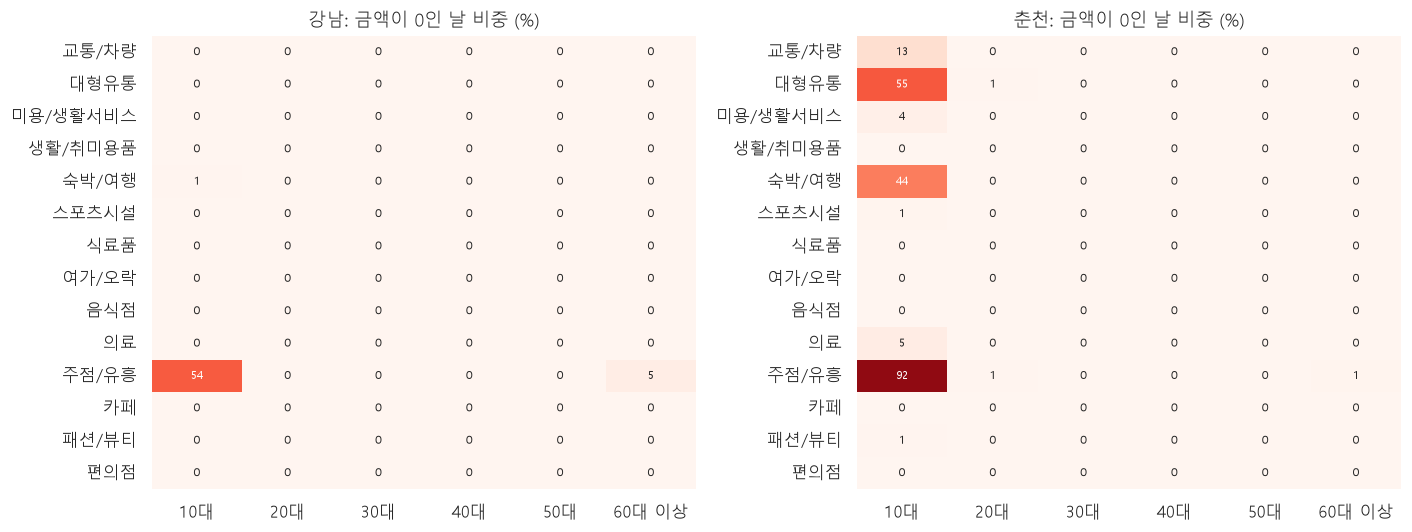

0인 날이 10%를 넘는 칸


,region,industry_group,age_g,0인 날 비중(%)
0,춘천,주점/유흥,10대,91.720
1,춘천,대형유통,10대,54.945
2,강남,주점/유흥,10대,53.933
3,춘천,숙박/여행,10대,44.022
4,춘천,교통/차량,10대,13.043


In [6]:
# 칸마다 184일 중 금액이 0인 날이 몇 %인지 센다.
빈날 = (cross.assign(비었나=cross['amount'].eq(0))
        .groupby(['region', 'industry_group', 'age_g'], observed=True)['비었나']
        .mean().mul(100).rename('0인 날 비중(%)').reset_index())

print(f'전체 {len(cross):,}행 중 금액이 0인 행 {int(cross["amount"].eq(0).sum()):,}개'
      f' ({cross["amount"].eq(0).mean() * 100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, REGIONS):
    t = (빈날[빈날['region'].eq(r)]
         .pivot(index='industry_group', columns='age_g', values='0인 날 비중(%)')[ALL_AGES])
    sns.heatmap(t, annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=100, ax=ax,
                cbar=False, annot_kws={'size': 7})
    ax.set(title=f'{r}: 금액이 0인 날 비중 (%)', xlabel='', ylabel='')
plt.tight_layout(); plt.show()

print('0인 날이 10%를 넘는 칸')
display(빈날[빈날['0인 날 비중(%)'] > 10].sort_values('0인 날 비중(%)', ascending=False)
        .reset_index(drop=True))

### 1-3. 10대를 본 분석에서 빼는 이유

In [7]:
# 연령대별로 "쓸 수 있는 칸"이 몇 개인지 정리한다.
요약 = (빈날.assign(성긴칸=빈날['0인 날 비중(%)'] > 10)
        .groupby('age_g')
        .agg(칸_수=('성긴칸', 'size'), 성긴_칸=('성긴칸', 'sum'),
             최대_0인날_비중=('0인 날 비중(%)', 'max'))
        .reindex(ALL_AGES))
요약['금액 비중(%)'] = (cross.groupby('age_g', observed=True)['amount'].sum()
                    / cross['amount'].sum() * 100).reindex(ALL_AGES)
display(요약.round(2))

print('10대 칸의 0인 날 비중 (%)')
display(빈날[빈날['age_g'].eq('10대')]
        .pivot(index='industry_group', columns='region', values='0인 날 비중(%)')
        .sort_values('춘천', ascending=False).round(1))

main = cross[cross['age_g'].isin(MAIN_AGES)].copy()
teen = cross[cross['age_g'].eq('10대')].copy()
print(f'본 분석 main {len(main):,}행 (칸 {main.groupby(["region", "industry_group", "age_g"], observed=True).ngroups}개, '
      f'0인 날 {main["amount"].eq(0).mean() * 100:.2f}%)')
print(f'따로 볼 teen {len(teen):,}행 (칸 {teen.groupby(["region", "industry_group"], observed=True).ngroups}개, '
      f'0인 날 {teen["amount"].eq(0).mean() * 100:.2f}%)')

,칸_수,성긴_칸,최대_0인날_비중,금액 비중(%)
age_g,,,,
10대,28,5,91.720,0.460
20대,28,0,0.540,9.850
30대,28,0,0.000,22.750
40대,28,0,0.000,26.270
50대,28,0,0.000,22.800
60대 이상,28,0,4.890,17.880


10대 칸의 0인 날 비중 (%)


region,강남,춘천
industry_group,,
주점/유흥,53.900,91.700
대형유통,0.000,54.900
숙박/여행,0.500,44.000
교통/차량,0.000,13.000
의료,0.000,5.400
미용/생활서비스,0.000,3.800
스포츠시설,0.000,1.100
패션/뷰티,0.000,0.500
생활/취미용품,0.000,0.000


본 분석 main 25,760행 (칸 140개, 0인 날 0.05%)
따로 볼 teen 5,117행 (칸 28개, 0인 날 9.11%)


**10대를 빼는 이유** (위 표가 근거다)

1. **금액이 너무 작다.** 10대는 전체 개인 결제 금액의 **0.46%** 다. 나머지 다섯 연령대는 한 곳도 10% 밑으로 내려가지 않는다.
2. **칸이 비어 있다.** 10대 칸 28개 중 5개는 0인 날이 10%를 넘고, 춘천 주점/유흥은 **184일 중 91.7%가 0** 이다.
   0인 날은 로그를 쓸 수 없어 회귀에서 통째로 빠진다. 춘천 주점/유흥 10대는 15일치로 날씨 효과를 재는 셈이 된다.
3. **한 칸이 깨지면 표 전체가 깨진다.** 3장은 업종그룹 x 연령 히트맵을 그리는데, 빈 칸이 섞이면 같은 눈금으로 비교할 수 없다.
4. **뺀다고 결과가 달라지지 않는다.** 0.46%짜리 연령대라 업종그룹 합계에 미치는 영향이 거의 없다.

> 대신 **9장에서 10대만 따로** 본다. 0인 날이 적은 칸은 그대로 회귀하고, 성긴 칸은 금액 대신 **"그날 결제가 있었나 없었나"** 로 바꿔서 본다.
> 성긴 데이터를 버리는 게 아니라, **성긴 데이터에 맞는 질문으로 바꿔서** 묻는 것이다.

### 1장 정리
- **본 것**: 날짜 x 지역 x 업종그룹 x 연령 교차 패널(30,877행, 168칸)을 만들고 칸마다 0인 날 비중을 셌다.
- **나온 것**: 문제가 되는 칸은 **전부 10대**다. 10대 칸 28개 중 5개가 0인 날 10%를 넘고(춘천 주점/유흥 91.7%, 춘천 대형유통 54.9%, 강남 주점/유흥 53.9%, 춘천 숙박/여행 44.0%, 춘천 교통/차량 13.0%), 금액 비중은 0.46%다.
  나머지 다섯 연령대는 28칸씩 모두 깨끗하고(최대 4.9%), 금액 비중도 9.9 ~ 26.3%로 고르다.
- **시사점**: 10대를 빼면 남는 140칸은 0인 날이 0.05%뿐이라 **같은 눈금의 히트맵**을 그릴 수 있다. 10대는 버리지 않고 9장에서 다른 질문으로 다시 묻는다.

## 2. 조건별 평균 (회귀 전에 눈으로)
회귀를 돌리기 전에 **날것에 가까운 그림**을 먼저 본다. 요일만 보정한 매출을 폭염일, 호우일, 평상일로 나눠 평균을 비교한다.
회귀 결과가 여기서 본 모양과 크게 다르면, 회귀식 어딘가를 의심해야 한다.

### 2-1. 요일 보정 매출

In [8]:
# 요일 효과가 워낙 커서(05번 2-2: 강남 일요일 -38%) 그대로 비교하면 날씨가 아니라 요일을 보게 된다.
# 칸마다 "그 칸의 그 요일 평균"으로 나눠, 1.0이면 그 칸의 그 요일치고 평균만큼 팔렸다는 뜻으로 만든다.
칸요일평균 = main.groupby(['region', 'industry_group', 'age_g', 'dow'], observed=True)['amount'].transform('mean')
main['adj'] = main['amount'] / 칸요일평균

display(main.groupby('region', observed=True)['adj']
        .describe()[['count', 'mean', '50%', 'min', 'max']].round(2))
print('-> 평균이 1 근처면 보정이 제대로 된 것이다. 이제 adj의 날씨별 평균을 비교하면 된다.')

,count,mean,50%,min,max
region,,,,,
강남,"12,880.000",1.000,0.980,0.000,8.160
춘천,"12,880.000",1.000,0.960,0.000,14.080


-> 평균이 1 근처면 보정이 제대로 된 것이다. 이제 adj의 날씨별 평균을 비교하면 된다.


### 2-2. 날씨 조건별 히트맵

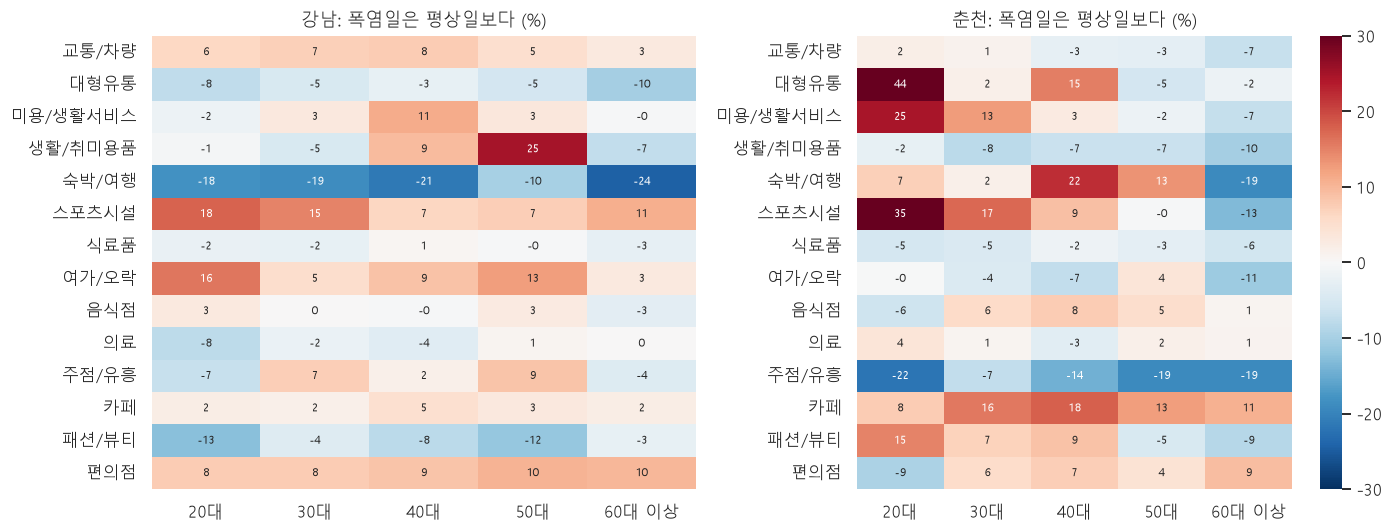

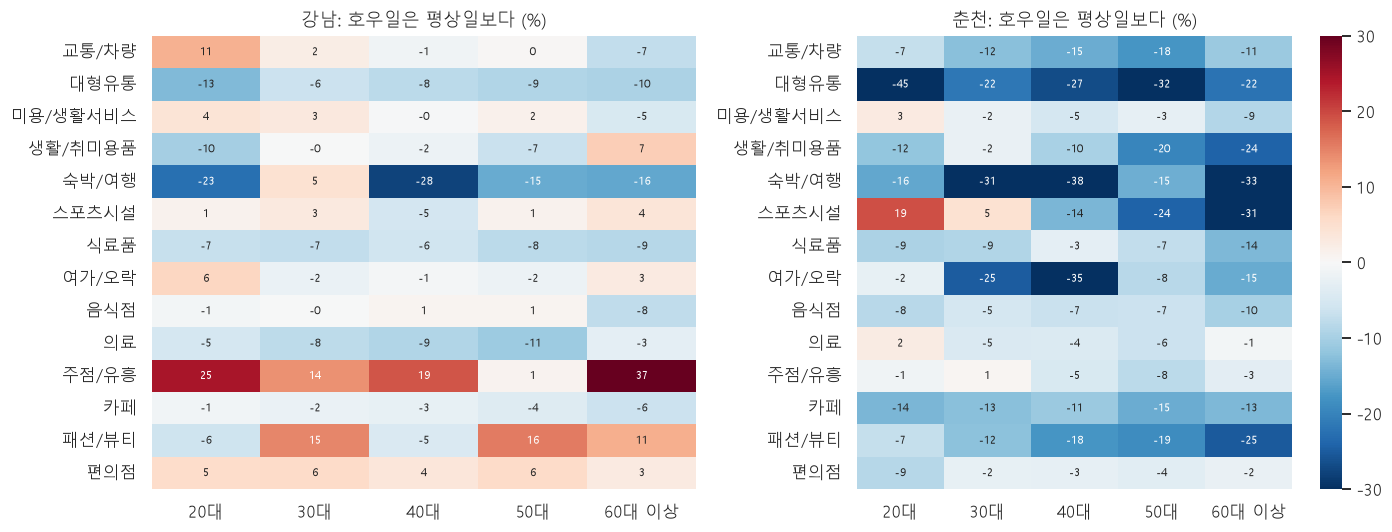

-> 요일만 보정한 날것의 그림이다. 월, 공휴일, 추석은 아직 안 걷어냈다.
-> 춘천 호우 쪽에 파란색(음수)이 넓게 깔리고, 폭염 쪽에는 그만한 덩어리가 없다. 05번 3장과 같은 모양이다.


In [9]:
def 조건비(flag):
    # (그 날씨인 날의 adj 평균) / (평상일 adj 평균) - 1, % 로
    t = main.groupby(['region', 'industry_group', 'age_g'], observed=True).apply(
        lambda g: (g.loc[g[flag], 'adj'].mean() / g.loc[g['normal'], 'adj'].mean() - 1) * 100,
        include_groups=False).rename('비율(%)').reset_index()
    return t


for flag in ['heat33', 'rain30']:
    t = 조건비(flag)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, r in zip(axes, REGIONS):
        표 = t[t['region'].eq(r)].pivot(index='industry_group', columns='age_g', values='비율(%)')[MAIN_AGES]
        sns.heatmap(표, annot=True, fmt='.0f', cmap='RdBu_r', center=0, vmin=-30, vmax=30,
                    ax=ax, cbar=(ax is axes[1]), annot_kws={'size': 7})
        ax.set(title=f'{r}: {WX_NAME[flag]}일은 평상일보다 (%)', xlabel='', ylabel='')
    plt.tight_layout(); plt.show()

print('-> 요일만 보정한 날것의 그림이다. 월, 공휴일, 추석은 아직 안 걷어냈다.')
print('-> 춘천 호우 쪽에 파란색(음수)이 넓게 깔리고, 폭염 쪽에는 그만한 덩어리가 없다. 05번 3장과 같은 모양이다.')

### 2장 정리
- **본 것**: 요일만 보정한 매출로 폭염일, 호우일이 평상일보다 몇 % 다른지 업종그룹 x 연령 히트맵을 그렸다.
- **나온 것**: 춘천 호우 쪽만 음수가 넓게 깔린다. 폭염 쪽은 부호가 섞여 있고 큰 값도 양수 쪽에 있다.
- **시사점**: 회귀로 달력을 제대로 걷어내기 전에도 **호우 중심**이라는 05번의 결론이 그대로 보인다. 3장의 회귀 결과가 이 모양에서 크게 벗어나면 식을 의심해야 한다.

## 3. 효과 히트맵
칸(지역 x 업종그룹 x 연령) 하나에 회귀 하나. 식은 05번 3-3과 같고, 업종그룹과 연령이 이미 칸으로 고정되어 있으므로 고정효과 항은 필요 없다.

`y ~ 요일 + 공휴일 + 월 + 추석 연휴 + 추석 3일 + heat33 + tropical + rain30`

표준오차는 `HC1`(날마다 흔들림 크기가 달라도 버티는 방식)을 쓴다. 칸 하나가 184행짜리 회귀다.

### 3-1. 칸마다 회귀 140개

In [10]:
def 효과뽑기(m):
    # 회귀 결과에서 날씨 계수 3개를 % 효과와 95% 신뢰구간으로 바꾼다.
    ci = m.conf_int()
    행 = []
    for v in WX_VARS:
        if v not in m.params.index:
            continue
        행.append({'var': v.split('[')[0],
                   'eff': (np.exp(m.params[v]) - 1) * 100,
                   'lo': (np.exp(ci.loc[v, 0]) - 1) * 100,
                   'hi': (np.exp(ci.loc[v, 1]) - 1) * 100,
                   'p': m.pvalues[v]})
    return pd.DataFrame(행)


WX_FORMULA = 'y ~ ' + CAL_FORMULA + ' + heat33 + tropical + rain30'

행 = []
for (r, g, a), q in main.groupby(['region', 'industry_group', 'age_g'], observed=True):
    q = q[q['y'].notna()]
    m = smf.ols(WX_FORMULA, data=q).fit(cov_type='HC1')
    t = 효과뽑기(m)
    t.insert(0, 'age', a); t.insert(0, 'group', g); t.insert(0, 'region', r)
    t['n'] = len(q)
    행.append(t)
eff = pd.concat(행, ignore_index=True)
eff['날씨'] = eff['var'].map(WX_NAME)
eff['유의'] = eff['p'] < 0.05

print(f'회귀 {len(eff) // 3}개 완료 (칸 하나당 {eff["n"].min()} ~ {eff["n"].max()}일)')
display(eff.groupby('날씨')['유의'].agg(유의한_칸='sum', 전체_칸='size'))
print('-> 효과가 전혀 없어도 140칸 중 7칸 정도는 우연히 p < 0.05가 된다. 이 숫자를 기준으로 읽는다.')

회귀 140개 완료 (칸 하나당 175 ~ 184일)


,유의한_칸,전체_칸
날씨,,
열대야,18,140
폭염,34,140
호우,34,140


-> 효과가 전혀 없어도 140칸 중 7칸 정도는 우연히 p < 0.05가 된다. 이 숫자를 기준으로 읽는다.


### 3-2. 히트맵 그리기

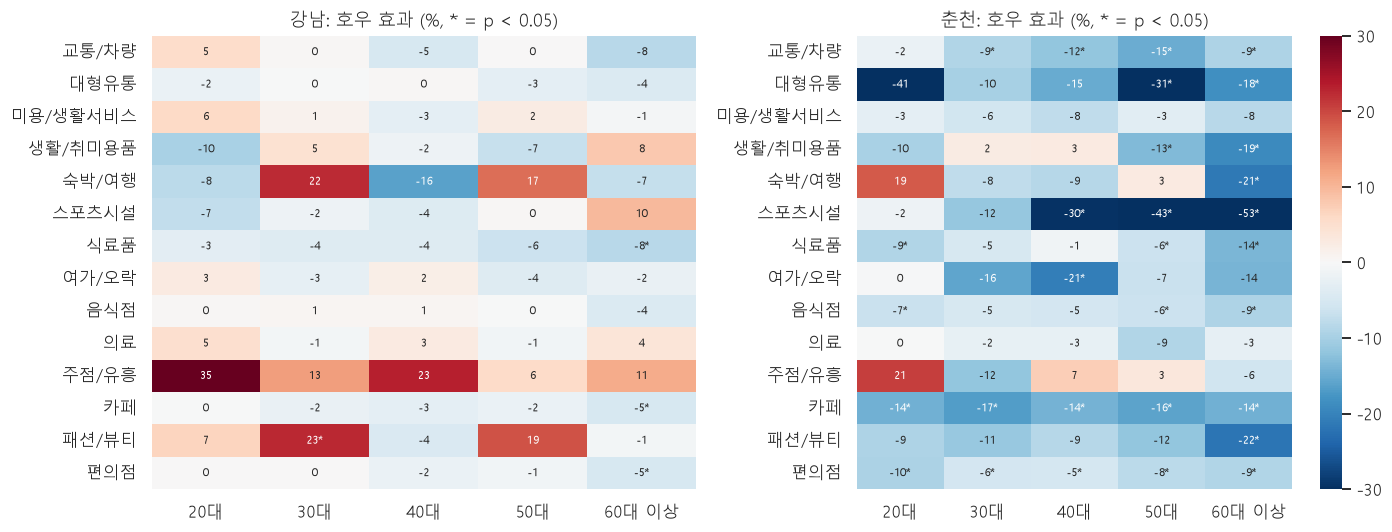

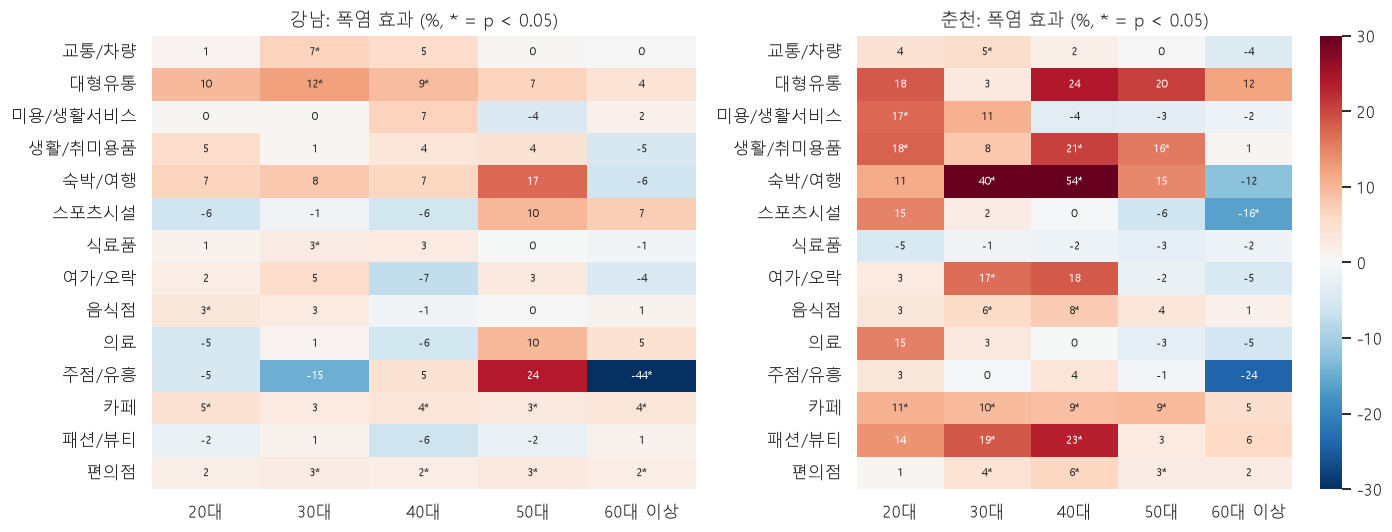

-> 춘천 호우(왼쪽 아래 그림의 오른쪽 판)만 한 덩어리로 파랗다. 나머지 세 판은 빨강과 파랑이 섞여 있다.
-> 섞여 있다는 것은 "효과가 있는데 방향이 다르다"가 아니라 "효과가 없어서 우연히 흩어져 있다"에 가깝다. 3-3에서 확인한다.


In [11]:
def 효과히트맵(v, vmax=25):
    t = eff[eff['var'].eq(v)]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, r in zip(axes, REGIONS):
        s = t[t['region'].eq(r)]
        값 = s.pivot(index='group', columns='age', values='eff')[MAIN_AGES]
        별 = s.pivot(index='group', columns='age', values='유의')[MAIN_AGES]
        라벨 = 값.round(0).astype(int).astype(str) + np.where(별, '*', '')
        sns.heatmap(값, annot=라벨, fmt='', cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                    ax=ax, cbar=(ax is axes[1]), annot_kws={'size': 7})
        ax.set(title=f'{r}: {WX_NAME[v]} 효과 (%, * = p < 0.05)', xlabel='', ylabel='')
    plt.tight_layout(); plt.show()


효과히트맵('rain30', vmax=30)
효과히트맵('heat33', vmax=30)
print('-> 춘천 호우(왼쪽 아래 그림의 오른쪽 판)만 한 덩어리로 파랗다. 나머지 세 판은 빨강과 파랑이 섞여 있다.')
print('-> 섞여 있다는 것은 "효과가 있는데 방향이 다르다"가 아니라 "효과가 없어서 우연히 흩어져 있다"에 가깝다. 3-3에서 확인한다.')

### 3-3. 다중검정 보정
140칸을 각각 검정하면, **효과가 하나도 없어도** 평균 7칸이 우연히 p < 0.05가 된다.
그래서 "유의한 칸이 몇 개 나왔나"를 우연히 나올 개수와 비교하고, **BH 보정**(Benjamini-Hochberg)으로 걸러 본다.
BH는 "유의하다고 부른 칸들 중 가짜가 5%를 넘지 않게" p값 문턱을 조절하는 방법이다.

In [12]:
eff['q'] = np.nan
eff['BH통과'] = False      # 아래에서 채운다 (처음부터 True/False 열로 만들어 둔다)

행 = []
for v in ['heat33', 'tropical', 'rain30']:
    t = eff[eff['var'].eq(v)].copy()
    통과, q값, *_ = multipletests(t['p'], alpha=0.05, method='fdr_bh')
    eff.loc[t.index, 'q'] = q값
    eff.loc[t.index, 'BH통과'] = 통과
    행.append({'날씨': WX_NAME[v], '칸 수': len(t), 'p<0.05 칸': int(t['p'].lt(0.05).sum()),
               '우연히 나올 개수': round(len(t) * 0.05, 1), 'BH 통과 칸': int(통과.sum())})
display(pd.DataFrame(행).set_index('날씨'))

print('BH를 통과한 칸 (가짜일 확률을 5%로 묶은 뒤에도 살아남은 칸)')
display(eff[eff['BH통과']]
        .sort_values(['var', 'eff'])[['region', 'group', 'age', '날씨', 'eff', 'lo', 'hi', 'q']]
        .round(2).reset_index(drop=True))
print('-> 폭염은 BH를 통과하는 칸이 0개다. 업종그룹 x 연령까지 쪼개도 폭염이 매출을 누른다는 증거는 없다.')
print('-> 호우는 통과 칸이 대부분 춘천이다. 강남에서 우연히 유의했던 칸들은 BH에서 떨어진다.')

,칸 수,p<0.05 칸,우연히 나올 개수,BH 통과 칸
날씨,,,,
폭염,140,34,7.000,0
열대야,140,18,7.000,1
호우,140,34,7.000,24


BH를 통과한 칸 (가짜일 확률을 5%로 묶은 뒤에도 살아남은 칸)


,region,group,age,날씨,eff,lo,hi,q
0,춘천,스포츠시설,60대 이상,호우,-52.740,-65.580,-35.110,0.000
1,춘천,스포츠시설,50대,호우,-42.800,-53.470,-29.690,0.000
2,춘천,스포츠시설,40대,호우,-29.650,-39.780,-17.820,0.000
3,춘천,패션/뷰티,60대 이상,호우,-22.020,-33.170,-9.000,0.010
4,춘천,생활/취미용품,60대 이상,호우,-19.090,-28.700,-8.170,0.010
5,춘천,카페,30대,호우,-16.700,-22.510,-10.450,0.000
6,춘천,카페,50대,호우,-16.060,-21.630,-10.110,0.000
7,춘천,교통/차량,50대,호우,-14.820,-20.210,-9.070,0.000
8,춘천,카페,60대 이상,호우,-14.460,-21.620,-6.640,0.000
9,춘천,카페,20대,호우,-14.340,-19.600,-8.730,0.000


-> 폭염은 BH를 통과하는 칸이 0개다. 업종그룹 x 연령까지 쪼개도 폭염이 매출을 누른다는 증거는 없다.
-> 호우는 통과 칸이 대부분 춘천이다. 강남에서 우연히 유의했던 칸들은 BH에서 떨어진다.


### 3장 정리
- **본 것**: 칸마다 회귀 140개를 돌려 폭염, 호우 % 효과를 히트맵으로 그리고, 다중검정 보정으로 걸렀다.
- **나온 것**: 폭염과 호우 **둘 다 p < 0.05인 칸이 34개씩** 나왔다(우연히 나올 개수는 7개). 그런데 **BH를 통과한 칸은 호우 24개, 폭염 0개**다.
  폭염에서 유의해 보이던 34칸은 방향이 제각각이고 p값도 경계에 몰려 있어 보정에서 모두 떨어진다.
  호우 통과 24칸은 강남 2칸(60대 이상 카페 -5.0%, 편의점 -5.0%)과 강남 패션/뷰티 30대(+22.7%)를 빼면 전부 춘천이다.
  춘천 호우에서 연령을 따라 깊어지는 칸이 보인다 - 스포츠시설 20대 -1.5%에서 60대 이상 -52.7%, 패션/뷰티 -9.2%에서 -22.0%.
- **시사점**: 쪼개 봐도 **폭염은 여전히 없고 호우만 있다**(05번 3장과 같음). "유의한 칸이 34개나 나왔다"는 말이 얼마나 위험한지도 여기서 드러난다.
  다만 이 히트맵은 칸마다 따로 돌린 값이라 "연령 사이에 차이가 있다"를 아직 말할 수 없다. 4장에서 한 식으로 검정한다.

## 4. 연령 차이가 진짜인가 (상호작용 검정)
3장의 히트맵에서 "20대 -1.5%, 60대 이상 -52.7%"처럼 보이는 것과, **"두 연령의 효과가 서로 다르다"** 를 통계로 말하는 것은 다른 일이다.
칸마다 따로 돌린 계수는 각자의 오차를 갖고 있어서, 둘을 눈으로 빼면 안 된다.

한 업종그룹 안에서 연령을 모두 넣은 **하나의 식**을 돌리고, 연령과 날씨의 **교차항이 전부 0인가**를 F검정한다.

`y ~ C(age_g) + 달력 + heat33 + tropical + rain30 + C(age_g):rain30`

교차항이 0이 아니면 "이 업종그룹에서는 비 효과가 연령마다 다르다"고 말할 수 있다.
표준오차는 같은 날의 연령 5개가 서로 독립이 아니므로 **날짜로 묶어(cluster)** 계산한다.

### 4-1. 업종그룹마다 교차항 F검정

In [13]:
행 = []
for (r, g), q in main.groupby(['region', 'industry_group'], observed=True):
    q = q[q['y'].notna()].copy()
    for v in ['heat33', 'rain30']:
        f = f'y ~ C(age_g) + {CAL_FORMULA} + heat33 + tropical + rain30 + C(age_g):{v}'
        m = smf.ols(f, data=q).fit(cov_type='cluster',
                                   cov_kwds={'groups': q['date'].factorize()[0]})
        교차항 = [c for c in m.params.index if 'C(age_g)[T.' in c and f':{v}' in c]
        ft = m.f_test(' = 0, '.join(교차항) + ' = 0')
        행.append({'지역': r, '업종그룹': g, '날씨': WX_NAME[v],
                   'F': float(ft.fvalue), 'p': float(ft.pvalue)})
inter = pd.DataFrame(행)
inter['연령차이 있음'] = inter['p'] < 0.05

display(inter.groupby('날씨')['연령차이 있음'].agg(유의한_그룹='sum', 전체_그룹='size'))
for 이름 in ['호우', '폭염']:
    print(f'{이름}: 연령에 따라 효과가 다른 업종그룹 (p가 작은 순)')
    display(inter[inter['날씨'].eq(이름) & inter['연령차이 있음']]
            .sort_values('p')[['지역', '업종그룹', 'F', 'p']].round(4).reset_index(drop=True))

,유의한_그룹,전체_그룹
날씨,,
폭염,10,28
호우,9,28


호우: 연령에 따라 효과가 다른 업종그룹 (p가 작은 순)


,지역,업종그룹,F,p
0,강남,패션/뷰티,15.154,0.000
1,강남,음식점,5.883,0.000
2,강남,식료품,4.000,0.004
3,강남,교통/차량,3.726,0.006
4,강남,편의점,3.636,0.007
5,강남,카페,3.113,0.017
6,강남,숙박/여행,3.100,0.017
7,춘천,식료품,2.778,0.028
8,춘천,스포츠시설,2.631,0.036


폭염: 연령에 따라 효과가 다른 업종그룹 (p가 작은 순)


,지역,업종그룹,F,p
0,춘천,편의점,42.008,0.000
1,춘천,음식점,14.579,0.000
2,강남,생활/취미용품,6.075,0.000
3,강남,식료품,4.416,0.002
4,춘천,카페,3.861,0.005
5,강남,음식점,3.447,0.010
6,강남,미용/생활서비스,3.354,0.011
7,강남,카페,3.105,0.017
8,춘천,스포츠시설,3.002,0.020
9,강남,여가/오락,2.441,0.049


### 4-2. 살아남은 업종그룹의 연령 곡선
검정을 통과한 칸만 골라 연령을 x축에 놓고 효과를 선으로 그린다. **기울기가 곧 "연령 차이"** 다.

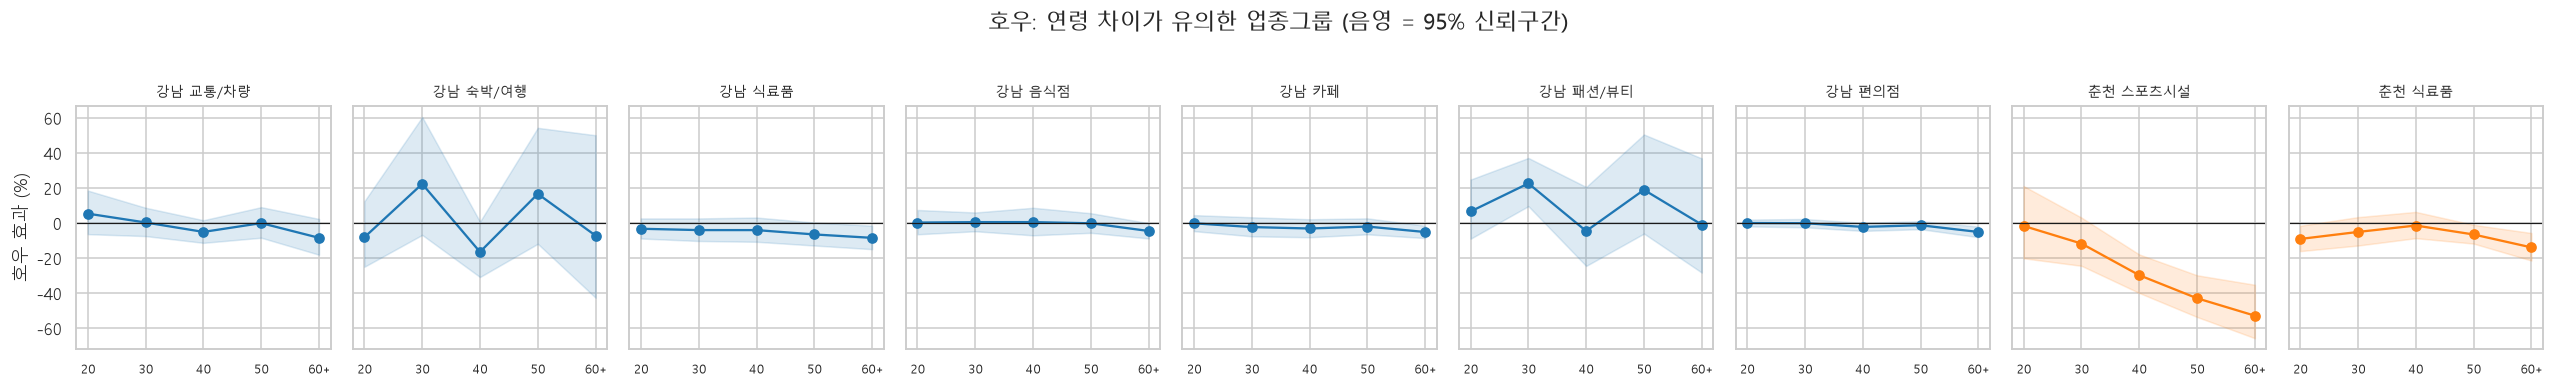

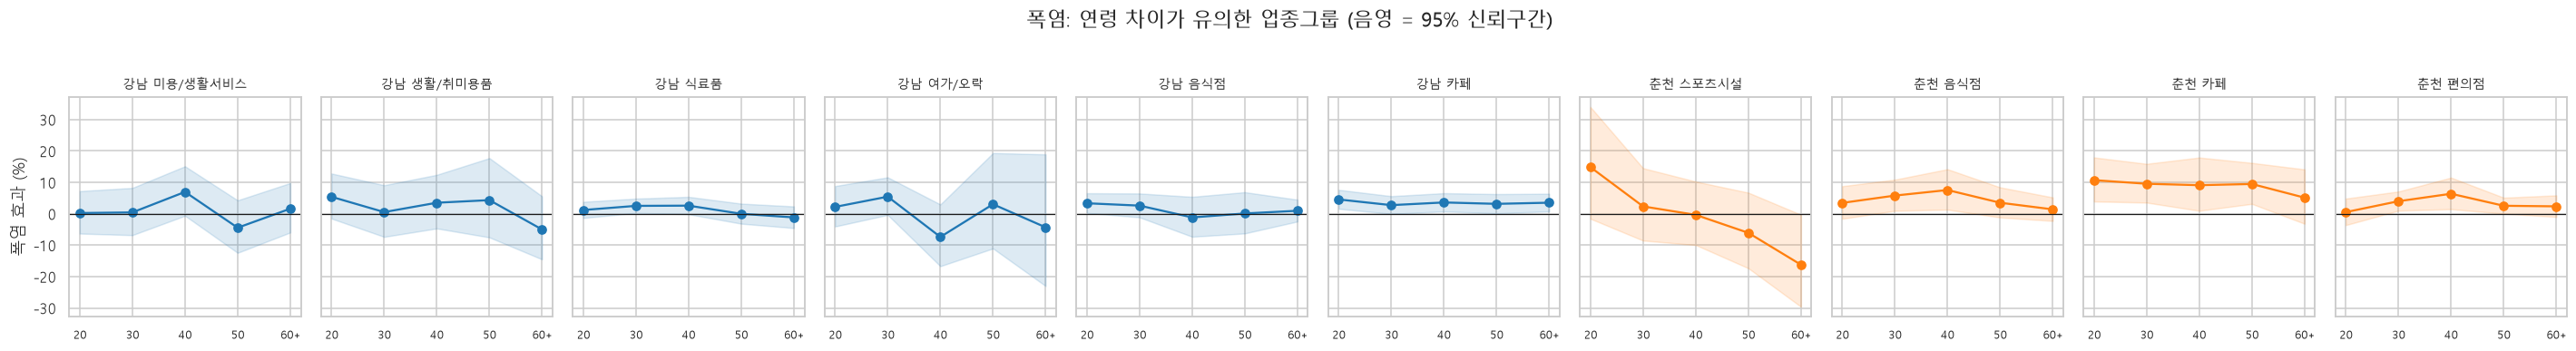

호우: 20대와 60대 이상의 효과 차이가 큰 칸 (음수 = 고령층이 더 크게 빠짐)


age               20대     30대     40대     50대  60대 이상     기울기
region group                                                 
춘천     스포츠시설   -1.500 -11.600 -29.700 -42.800 -52.700 -51.200
       숙박/여행   18.500  -7.600  -8.500   2.700 -21.400 -39.900
       주점/유흥   20.700 -11.900   7.400   3.400  -6.000 -26.800
강남     주점/유흥   35.000  12.600  23.400   5.600  11.100 -23.900
       교통/차량    5.500   0.400  -5.000   0.100  -8.300 -13.800
춘천     여가/오락   -0.400 -15.700 -20.800  -6.700 -14.000 -13.600
       패션/뷰티   -9.200 -11.500  -8.600 -11.800 -22.000 -12.800
       생활/취미용품 -9.700   2.400   2.800 -13.300 -19.100  -9.300

In [14]:
def 연령곡선(이름, v):
    통과 = inter[inter['날씨'].eq(이름) & inter['연령차이 있음']][['지역', '업종그룹']]
    if 통과.empty:
        print(f'{이름}: 통과한 업종그룹이 없다'); return
    t = eff[eff['var'].eq(v)].merge(통과, left_on=['region', 'group'], right_on=['지역', '업종그룹'])
    n = len(통과)
    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3.4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (_, x) in zip(axes, 통과.iterrows()):
        s = t[t['region'].eq(x['지역']) & t['group'].eq(x['업종그룹'])].set_index('age').reindex(MAIN_AGES)
        ax.plot(range(len(MAIN_AGES)), s['eff'], 'o-', color=REGION_COLOR[x['지역']])
        ax.fill_between(range(len(MAIN_AGES)), s['lo'], s['hi'],
                        color=REGION_COLOR[x['지역']], alpha=0.15)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(range(len(MAIN_AGES)))
        ax.set_xticklabels(['20', '30', '40', '50', '60+'], fontsize=8)
        ax.set_title(f'{x["지역"]} {x["업종그룹"]}', fontsize=9)
    axes[0].set_ylabel(f'{이름} 효과 (%)')
    fig.suptitle(f'{이름}: 연령 차이가 유의한 업종그룹 (음영 = 95% 신뢰구간)', y=1.03)
    plt.tight_layout(); plt.show()


연령곡선('호우', 'rain30')
연령곡선('폭염', 'heat33')

# 연령 기울기 = (60대 이상 효과) - (20대 효과). 양수면 나이가 많을수록 덜 빠진다는 뜻
기울기 = (eff[eff['var'].eq('rain30')].pivot_table(index=['region', 'group'], columns='age', values='eff')
        [MAIN_AGES].assign(기울기=lambda d: d['60대 이상'] - d['20대']))
print('호우: 20대와 60대 이상의 효과 차이가 큰 칸 (음수 = 고령층이 더 크게 빠짐)')
display(기울기.sort_values('기울기').head(8).round(1))

### 4장 정리
- **본 것**: 업종그룹마다 연령과 날씨의 교차항을 넣은 하나의 식을 돌려, 교차항이 전부 0인지 F검정했다.
- **나온 것**: 호우는 28개 조합 중 **9개**에서 연령 차이가 유의했고, 폭염도 **10개**에서 유의했다.
  폭염은 3장에서 **수준 효과가 BH를 하나도 통과하지 못했는데도** 연령 교차항은 유의하다. 즉 폭염은 매출 총액을 바꾸지 않으면서 **연령 구성을 바꾼다**.
- **시사점**: 히트맵의 기울기 중 실제로 말할 수 있는 것은 이 9개(호우), 10개(폭염)뿐이다. 나머지 칸의 기울기는 눈으로만 보고 주장하지 않는다.
  [추론] 폭염에서 총액은 그대로인데 연령 구성이 바뀌는 것은 "누군가 덜 쓰고 누군가 더 쓴다"는 뜻으로 보이지만, 이 데이터로는 같은 사람의 이동인지 다른 사람의 유입인지 구분할 수 없다.

## 5. 두 지역 비교
같은 칸(업종그룹 x 연령)을 강남과 춘천에서 나란히 놓는다. 05번 9-1을 연령까지 내린 것이다.
두 지역에서 같은 모양이면 "복제된다"고 말할 수 있고, 한쪽에만 있으면 그 지역 사정이다.

### 5-1. 업종그룹 격자와 덤벨 차트

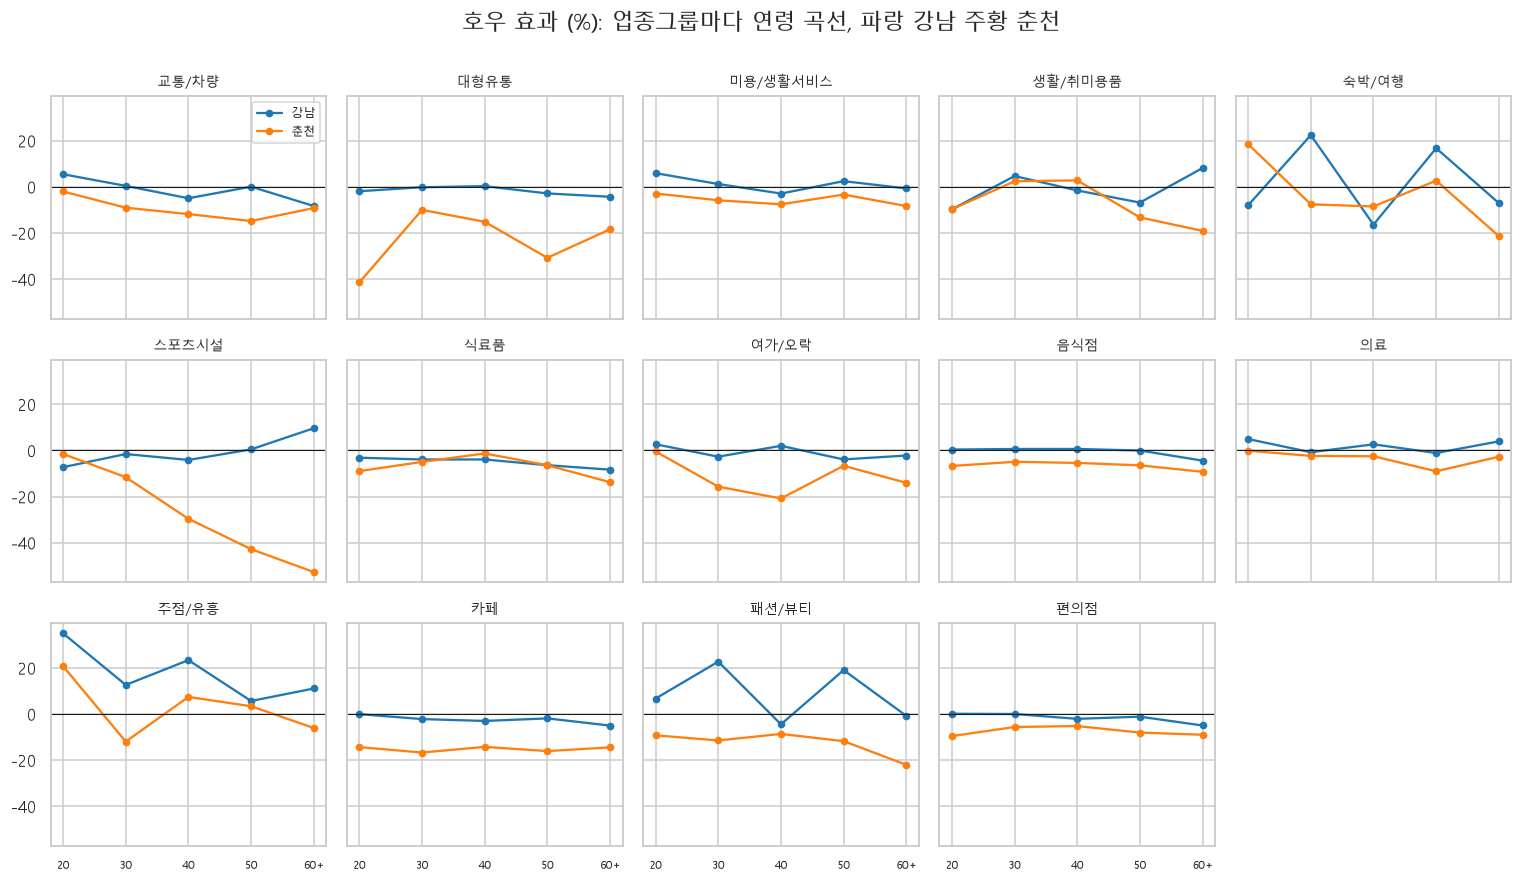

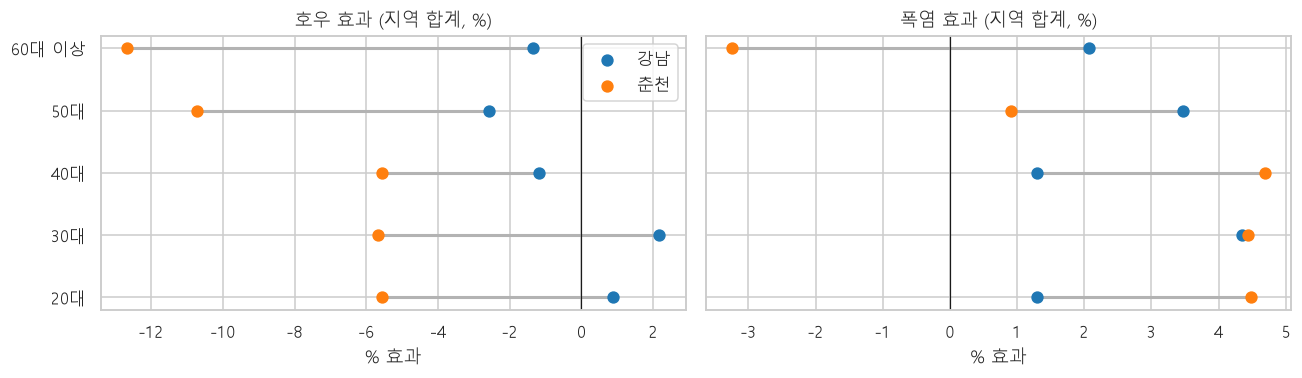

날씨,폭염,호우,폭염,호우
region,강남,강남,춘천,춘천
age,,,,
20대,1.300,0.900,4.500,-5.600
30대,4.300,2.200,4.400,-5.700
40대,1.300,-1.200,4.700,-5.600
50대,3.500,-2.600,0.900,-10.700
60대 이상,2.100,-1.400,-3.200,-12.700


-> 호우는 춘천에서만 연령을 따라 깊어진다. 강남은 모든 연령이 0 근처에 붙어 있다.


In [15]:
t = eff[eff['var'].eq('rain30')]
fig, axes = plt.subplots(3, 5, figsize=(14, 8), sharex=True, sharey=True)
for ax, g in zip(axes.ravel(), GROUPS):
    for r in REGIONS:
        s = t[t['region'].eq(r) & t['group'].eq(g)].set_index('age').reindex(MAIN_AGES)
        ax.plot(range(len(MAIN_AGES)), s['eff'], 'o-', color=REGION_COLOR[r], ms=4, label=r)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xticks(range(len(MAIN_AGES)))
    ax.set_xticklabels(['20', '30', '40', '50', '60+'], fontsize=7)
    ax.set_title(g, fontsize=9)
for ax in axes.ravel()[len(GROUPS):]:
    ax.axis('off')
axes[0, 0].legend(fontsize=8)
fig.suptitle('호우 효과 (%): 업종그룹마다 연령 곡선, 파랑 강남 주황 춘천', y=1.0)
plt.tight_layout(); plt.show()

# 연령별 지역 합계: 업종그룹을 모두 더한 일매출로 다시 회귀
행 = []
연령합 = add_wx_cal(base1[base1['age_g'].isin(MAIN_AGES)]
                  .groupby(['date', 'region', 'age_g'], as_index=False, observed=True)
                  .agg(amount=('amount', 'sum'), cnt=('cnt', 'sum')))
for (r, a), q in 연령합.groupby(['region', 'age_g'], observed=True):
    s = 효과뽑기(smf.ols(WX_FORMULA, data=q).fit(cov_type='HC1'))
    s.insert(0, 'age', a); s.insert(0, 'region', r)
    행.append(s)
연령효과 = pd.concat(행, ignore_index=True)
연령효과['날씨'] = 연령효과['var'].map(WX_NAME)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, v in zip(axes, ['rain30', 'heat33']):
    s = 연령효과[연령효과['var'].eq(v)].pivot(index='age', columns='region', values='eff').reindex(MAIN_AGES)
    y = range(len(s))
    ax.hlines(y, s['강남'], s['춘천'], color='0.7', lw=2, zorder=1)
    ax.scatter(s['강남'], y, color=REGION_COLOR['강남'], s=50, zorder=2, label='강남')
    ax.scatter(s['춘천'], y, color=REGION_COLOR['춘천'], s=50, zorder=2, label='춘천')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_yticks(list(y)); ax.set_yticklabels(s.index)
    ax.set(title=f'{WX_NAME[v]} 효과 (지역 합계, %)', xlabel='% 효과')
axes[0].legend()
plt.tight_layout(); plt.show()
display(연령효과[연령효과['var'].ne('tropical')]
        .pivot(index='age', columns=['날씨', 'region'], values='eff').reindex(MAIN_AGES).round(1))
print('-> 호우는 춘천에서만 연령을 따라 깊어진다. 강남은 모든 연령이 0 근처에 붙어 있다.')

### 5장 정리
- **본 것**: 업종그룹 14개 격자에 연령 곡선을 지역별로 겹쳐 그리고, 연령별 지역 합계를 덤벨 차트로 비교했다.
- **나온 것**: 춘천은 호우 효과가 20 ~ 40대 -5.6%에서 50대 -10.7%, 60대 이상 -12.7%로 **나이가 많아질수록 깊어진다.**
  강남은 모든 연령이 -2.6 ~ +2.2%로 0 근처에 붙어 있다. 폭염은 두 지역 모두 연령을 따라 움직이는 모양이 없다.
- **시사점**: 연령 기울기는 **춘천에만 있는 현상**이다. 두 지역에서 복제되지 않으므로 "비 오는 날 고령층이 더 빠진다"는 일반 법칙이 아니라 **춘천의 이동 구조에 대한 이야기**로 써야 한다.

## 6. 건수와 객단가 분해
`log(매출) = log(건수) + log(객단가)` 이므로 같은 식으로 회귀하면 계수가 정확히 더해진다.
건수가 줄었으면 **안 온 것**, 객단가가 줄었으면 **와서 덜 쓴 것**이다. 05번 5-1을 연령까지 내린다.

### 6-1. 칸마다 세 가지 y로 다시 회귀

호우: BH를 통과한 24칸의 분해


,지역,업종그룹,연령,매출(%),건수(%),객단가(%)
0,춘천,스포츠시설,60대 이상,-52.700,-17.600,-42.700
1,춘천,스포츠시설,50대,-42.800,-17.100,-31.000
2,춘천,스포츠시설,40대,-29.700,-9.300,-22.400
3,춘천,패션/뷰티,60대 이상,-22.000,-18.100,-4.700
4,춘천,생활/취미용품,60대 이상,-19.100,-16.300,-3.300
5,춘천,카페,30대,-16.700,-15.100,-1.900
6,춘천,카페,50대,-16.100,-14.300,-2.100
7,춘천,교통/차량,50대,-14.800,-11.300,-4.000
8,춘천,카페,60대 이상,-14.500,-14.500,0.000
9,춘천,카페,20대,-14.300,-13.600,-0.800


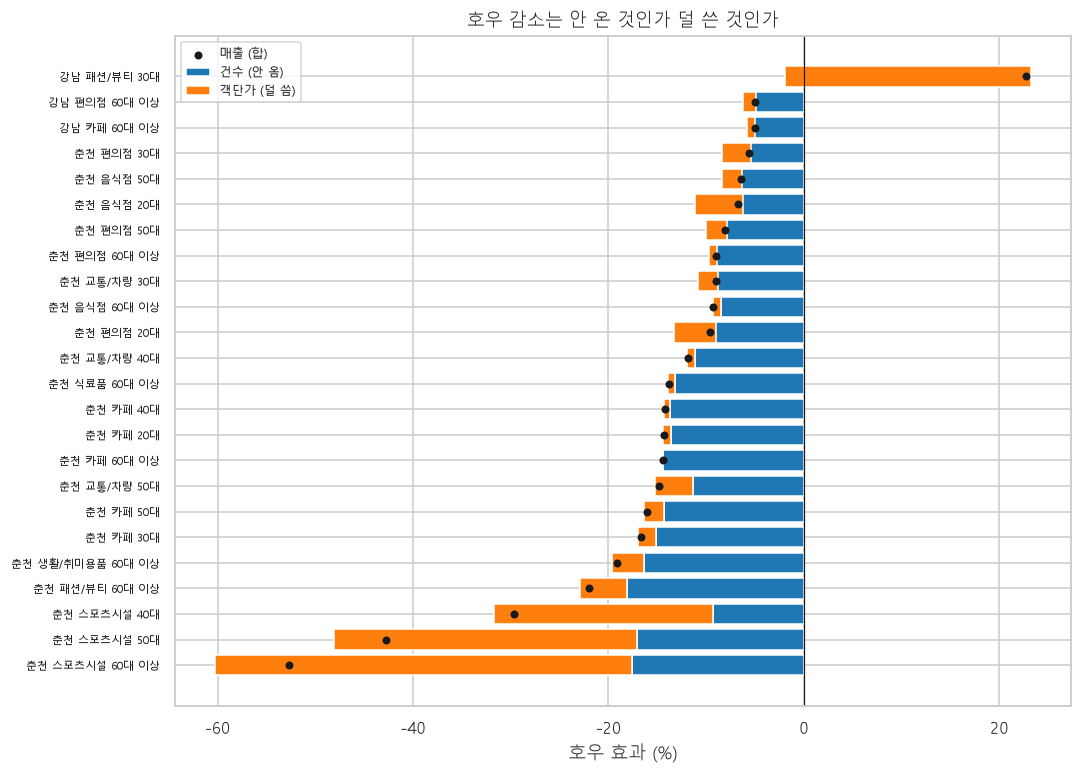

매출 감소 중 건수가 차지하는 몫: 중앙값 95%


In [16]:
행 = []
for (r, g, a), q in main.groupby(['region', 'industry_group', 'age_g'], observed=True):
    q = q[(q['amount'] > 0) & (q['cnt'] > 0)].copy()
    q['y_cnt'] = np.log(q['cnt'])
    q['y_tic'] = np.log(q['amount'] / q['cnt'])
    묶음 = {'지역': r, '업종그룹': g, '연령': a}
    for 이름, col in [('매출', 'y'), ('건수', 'y_cnt'), ('객단가', 'y_tic')]:
        m = smf.ols(f'{col} ~ ' + CAL_FORMULA + ' + heat33 + tropical + rain30',
                    data=q).fit(cov_type='HC1')
        묶음[f'{이름}(%)'] = (np.exp(m.params['rain30[T.True]']) - 1) * 100
    행.append(묶음)
분해 = pd.DataFrame(행)

# BH를 통과한 칸만 본다 (3-3)
통과칸 = eff[eff['var'].eq('rain30') & eff['BH통과']][['region', 'group', 'age']]
t = 분해.merge(통과칸, left_on=['지역', '업종그룹', '연령'], right_on=['region', 'group', 'age'])
t = t.sort_values('매출(%)')[['지역', '업종그룹', '연령', '매출(%)', '건수(%)', '객단가(%)']]
print(f'호우: BH를 통과한 {len(t)}칸의 분해')
display(t.round(1).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(t))))
y = range(len(t))
ax.barh(y, t['건수(%)'], color='tab:blue', label='건수 (안 옴)')
ax.barh(y, t['객단가(%)'], left=t['건수(%)'], color='tab:orange', label='객단가 (덜 씀)')
ax.scatter(t['매출(%)'], y, color='k', zorder=3, s=18, label='매출 (합)')
ax.set_yticks(list(y))
ax.set_yticklabels([f'{a} {b} {c}' for a, b, c in zip(t['지역'], t['업종그룹'], t['연령'])], fontsize=7)
ax.axvline(0, color='k', lw=0.8)
ax.set(xlabel='호우 효과 (%)', title='호우 감소는 안 온 것인가 덜 쓴 것인가')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

t2 = t.assign(건수몫=lambda d: d['건수(%)'] / d['매출(%)'] * 100)
print(f'매출 감소 중 건수가 차지하는 몫: 중앙값 {t2["건수몫"].median():.0f}%')

### 6장 정리
- **본 것**: BH를 통과한 호우 24칸마다 매출, 건수, 객단가로 나눠 회귀했다.
- **나온 것**: 매출 감소 중 **건수가 차지하는 몫의 중앙값이 95%** 다. 거의 전부가 "안 온 것"이다.
  예외는 춘천 스포츠시설로, 60대 이상 매출 -52.7% 중 건수는 -17.6%뿐이고 객단가가 -42.7%다(골프 같은 큰 결제가 사라짐).
  반대 방향의 유일한 칸인 강남 패션/뷰티 30대(+22.7%)도 건수가 아니라 객단가(+25.1%)로 움직인다.
- **시사점**: 연령까지 쪼개도 05번 5-1의 결론(감소 = 안 온 것)이 유지된다. 대책은 "와서 더 쓰게"가 아니라 **"비 와도 오게"** 쪽이다.
  다만 스포츠시설처럼 **큰 결제가 통째로 사라지는 업종**은 방문을 되살려도 금액이 안 돌아올 수 있다.

## 7. 이벤트 궤적과 회복 유형
여기까지는 "얼마나 빠지는가"(수준)였다. 이제 **"언제 돌아오는가"**(회복)를 연령별로 본다.
05번 6-4와 같은 방법으로, **평상일로만 학습한 기준선**을 칸마다 만들고 그 잔차를 사건 날짜에 줄 세운다.

### 7-1. 평상일 기준선과 소음 크기

In [17]:
행 = []
for (r, g, a), q in main.groupby(['region', 'industry_group', 'age_g'], observed=True):
    q = q.copy()
    # 평상일만으로 달력 식을 학습한 뒤, 그 식으로 모든 날의 기준선을 예측한다.
    # (금액이 0인 날은 y가 NaN이라 학습에서 자동으로 빠지고, 잔차도 NaN이 된다)
    m = smf.ols('y ~ ' + CAL_FORMULA, data=q[q['normal']]).fit()
    q['resid'] = q['y'] - m.predict(q)
    행.append(q[['date', 'region', 'industry_group', 'age_g', 'resid', 'normal']])
resid_ev = pd.concat(행, ignore_index=True)
print(f'resid_ev {len(resid_ev):,}행')

소음 = (resid_ev[resid_ev['normal']]
        .groupby(['region', 'age_g'], observed=True)['resid'].std().unstack('age_g')[MAIN_AGES] * 100)
display(소음.round(1).rename_axis('평상일 잔차 표준편차 (%)'))
print(f'-> 05번 6-4의 업종그룹 단위에서는 지역 합계가 7 ~ 9%였는데, 연령까지 쪼개니 {소음.min().min():.0f} ~ {소음.max().max():.0f}%로 커졌다.')
print('   칸이 작아진 만큼 하루 흔들림이 커진 것이다. 사건 하나로는 아무것도 말할 수 없고, 여러 사건을 평균 내야 한다.')

resid_ev 25,760행


age_g,20대,30대,40대,50대,60대 이상
평상일 잔차 표준편차 (%),,,,,
강남,28.700,22.200,24.200,28.000,36.500
춘천,40.900,34.600,34.700,32.600,30.500


-> 05번 6-4의 업종그룹 단위에서는 지역 합계가 7 ~ 9%였는데, 연령까지 쪼개니 22 ~ 41%로 커졌다.
   칸이 작아진 만큼 하루 흔들림이 커진 것이다. 사건 하나로는 아무것도 말할 수 없고, 여러 사건을 평균 내야 한다.


### 7-2. 호우 시작일 궤적 (연령별)

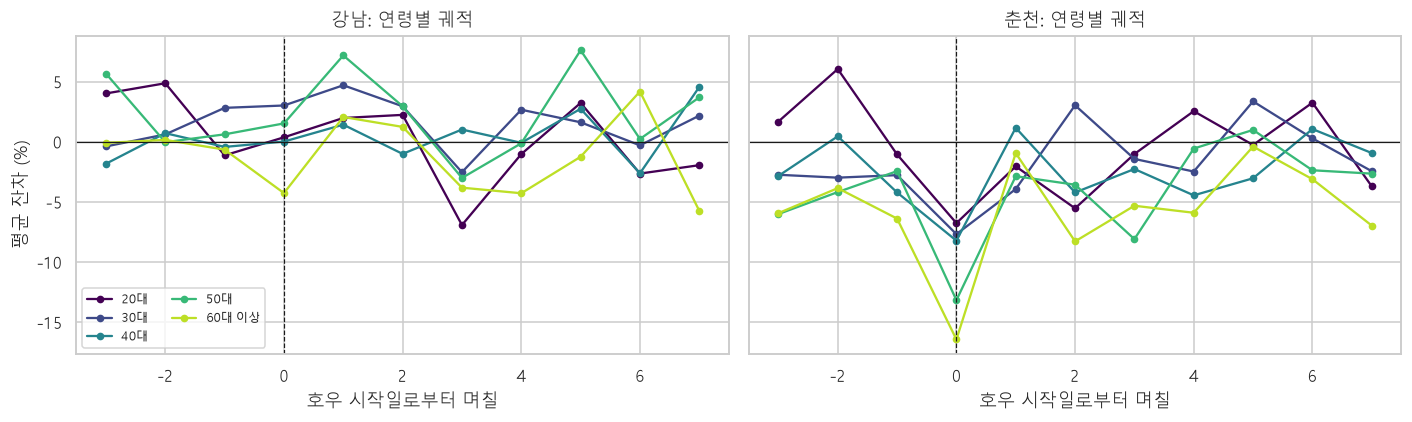

region     강남                                 춘천                              
age_g     20대    30대    40대    50대 60대 이상    20대    30대    40대     50대  60대 이상
k                                                                             
-3      4.000 -0.400 -1.800  5.700 -0.100  1.700 -2.700 -2.800  -6.000  -5.900
-2      4.900  0.600  0.700 -0.000  0.200  6.000 -3.000  0.500  -4.200  -3.900
-1     -1.100  2.800 -0.400  0.600 -0.700 -1.100 -2.800 -4.200  -2.400  -6.400
 0      0.400  3.000  0.000  1.500 -4.300 -6.800 -7.700 -8.200 -13.200 -16.400
 1      2.000  4.700  1.400  7.200  2.100 -2.000 -3.900  1.200  -2.900  -0.900
 2      2.200  2.900 -1.000  2.900  1.200 -5.500  3.000 -4.200  -3.600  -8.300
 3     -6.900 -2.500  1.000 -3.000 -3.800 -1.000 -1.400 -2.300  -8.100  -5.300
 4     -1.000  2.700 -0.100 -0.100 -4.300  2.500 -2.500 -4.500  -0.600  -5.900
 5      3.200  1.600  2.700  7.600 -1.200 -0.300  3.400 -3.000   1.000  -0.400
 6     -2.600 -0.300 -2.600  0.200  4.200  3.200  0.300  1.100  -2.400  -3.100
 7     -1.900  2.200  4.600  3.700 -5.700 -3.700 -2.400 -0.900  -2.700  -7.000

-> 춘천은 호우 당일(k=0) 20대 -6.8%에서 60대 이상 -16.4%로 연령을 따라 깊어진다.
-> 게다가 20 ~ 40대는 다음 날 0 근처로 올라오는데 60대 이상만 +7일까지 음수에 머문다. 크기뿐 아니라 회복 속도도 다르다.


In [18]:
def 궤적표(ev, 기준='start'):
    e = events[events['event'].eq(ev)]
    행 = []
    for _, x in e.iterrows():
        for k in range(WINDOW[0], WINDOW[1] + 1):
            행.append({'region': x['region'], 'spell_id': x['spell_id'], 'k': k,
                       'date': x[기준] + pd.Timedelta(days=k)})
    return pd.DataFrame(행).merge(resid_ev, on=['date', 'region'])


def 연령궤적(ev, 기준='start'):
    t = 궤적표(ev, 기준)
    s = (t.groupby(['region', 'age_g', 'k'], observed=True)['resid']
         .agg(['mean', 'sem']).reset_index())
    s[['mean', 'sem']] *= 100
    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    색 = plt.cm.viridis(np.linspace(0, 0.9, len(MAIN_AGES)))
    for ax, r in zip(axes, REGIONS):
        for c, a in zip(색, MAIN_AGES):
            g = s[s['region'].eq(r) & s['age_g'].eq(a)].sort_values('k')
            ax.plot(g['k'], g['mean'], 'o-', color=c, ms=4, label=a)
        ax.axhline(0, color='k', lw=0.8); ax.axvline(0, ls='--', color='k', lw=0.8)
        ax.set(xlabel=f'{EV_NAME[ev]} {"시작일" if 기준 == "start" else "종료일"}로부터 며칠',
               title=f'{r}: 연령별 궤적')
    axes[0].set_ylabel('평균 잔차 (%)'); axes[0].legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()
    return s


rain_traj = 연령궤적('rain30')
display(rain_traj.pivot(index='k', columns=['region', 'age_g'], values='mean')
        [[(r, a) for r in REGIONS for a in MAIN_AGES]].round(1))
print('-> 춘천은 호우 당일(k=0) 20대 -6.8%에서 60대 이상 -16.4%로 연령을 따라 깊어진다.')
print('-> 게다가 20 ~ 40대는 다음 날 0 근처로 올라오는데 60대 이상만 +7일까지 음수에 머문다. 크기뿐 아니라 회복 속도도 다르다.')

### 7-3. 업종그룹 격자 궤적 (춘천 호우)

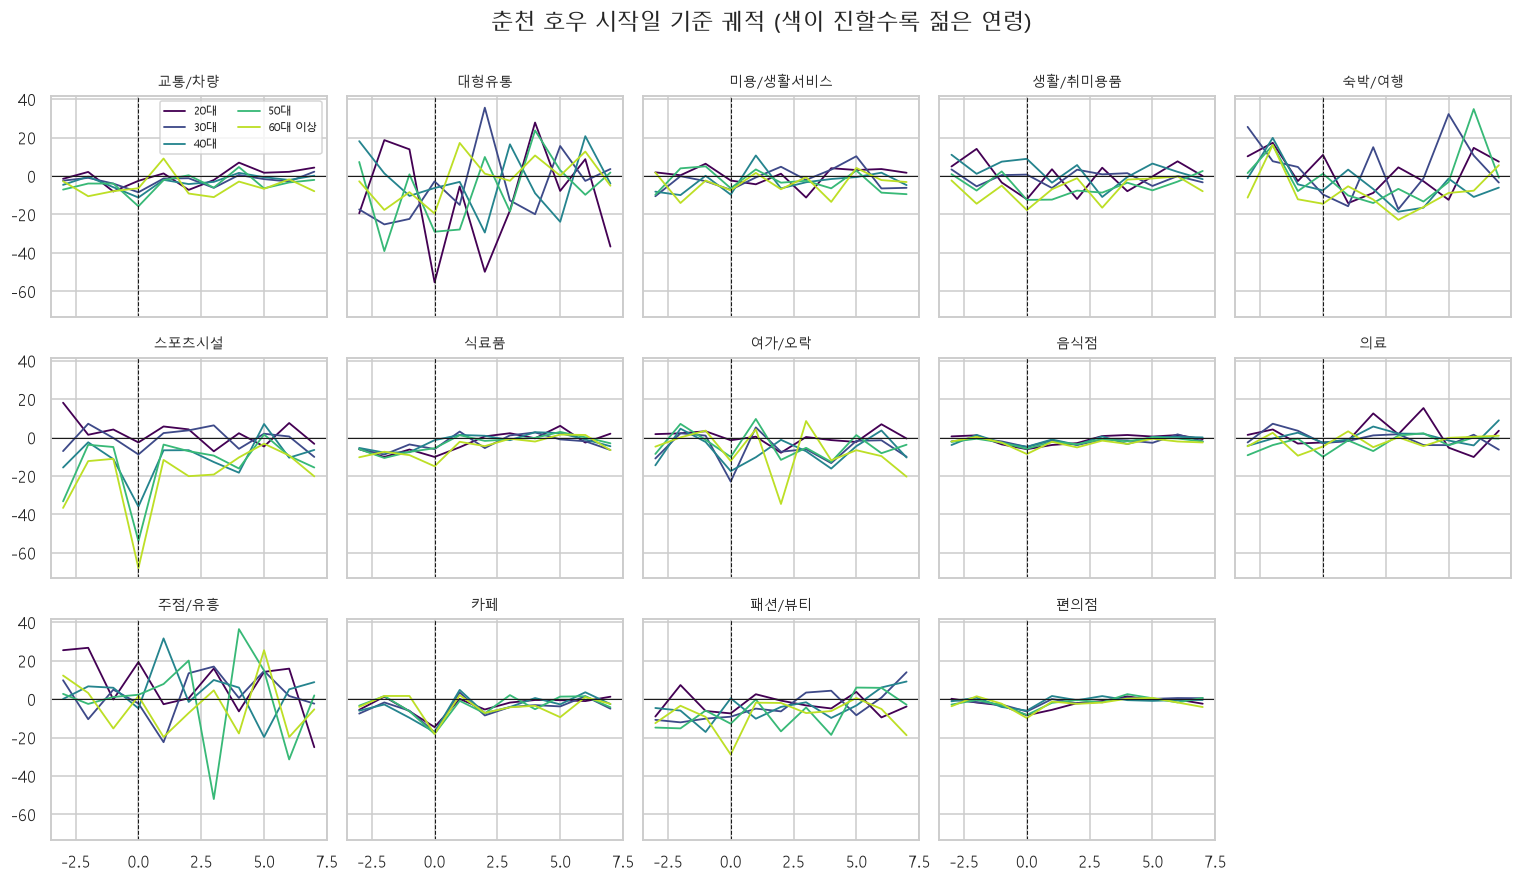

-> 카페, 편의점, 음식점은 모든 연령이 같이 내려갔다 같이 올라온다 (연령 차이 없음).
-> 스포츠시설, 여가/오락, 숙박/여행은 선이 넓게 벌어진다. 4장에서 연령 차이가 유의했던 칸들과 겹친다.


In [19]:
t = 궤적표('rain30')
t = t[t['region'].eq('춘천')]
s = t.groupby(['industry_group', 'age_g', 'k'], observed=True)['resid'].mean().mul(100).rename('mean').reset_index()

fig, axes = plt.subplots(3, 5, figsize=(14, 8), sharex=True, sharey=True)
색 = plt.cm.viridis(np.linspace(0, 0.9, len(MAIN_AGES)))
for ax, g in zip(axes.ravel(), GROUPS):
    for c, a in zip(색, MAIN_AGES):
        q = s[s['industry_group'].eq(g) & s['age_g'].eq(a)].sort_values('k')
        ax.plot(q['k'], q['mean'], color=c, lw=1.2, label=a)
    ax.axhline(0, color='k', lw=0.7); ax.axvline(0, ls='--', color='k', lw=0.7)
    ax.set_title(g, fontsize=9)
for ax in axes.ravel()[len(GROUPS):]:
    ax.axis('off')
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle('춘천 호우 시작일 기준 궤적 (색이 진할수록 젊은 연령)', y=1.0)
plt.tight_layout(); plt.show()
print('-> 카페, 편의점, 음식점은 모든 연령이 같이 내려갔다 같이 올라온다 (연령 차이 없음).')
print('-> 스포츠시설, 여가/오락, 숙박/여행은 선이 넓게 벌어진다. 4장에서 연령 차이가 유의했던 칸들과 겹친다.')

### 7-4. 회복 유형표
05번 8-1과 같은 규칙을 쓴다. `B = RECOVERY_BAND` (0.03).

| 순서 | 조건 | 유형 |
|---|---|---|
| 1 | 충격 중(during) 평균 잔차 > -B | 충격 없음 |
| 2 | 종료 후 1 ~ 3일 평균 >= -B | 즉시회복 |
| 3 | 종료 후 4 ~ 7일 평균 >= -B | 지연회복 |
| 4 | 둘 다 아님 | 미회복 |

> **주의**: 7-1에서 본 대로 이 단위의 하루 흔들림은 22 ~ 41%다. 05번(업종그룹 단위, 7 ~ 9%)보다 훨씬 크다.
> 같은 0.03 폭을 쓰면 **"충격 없음"이 줄고 "미회복"이 늘어난다.** 유형 하나하나가 아니라 **표 전체의 모양**으로 읽어야 한다.

유형          미회복  즉시회복  지연회복  충격 없음
이벤트 region                        
폭염  강남        8     6     0     56
    춘천        8     7     4     51
호우  강남        2    18     2     48
    춘천        8    41     9     12

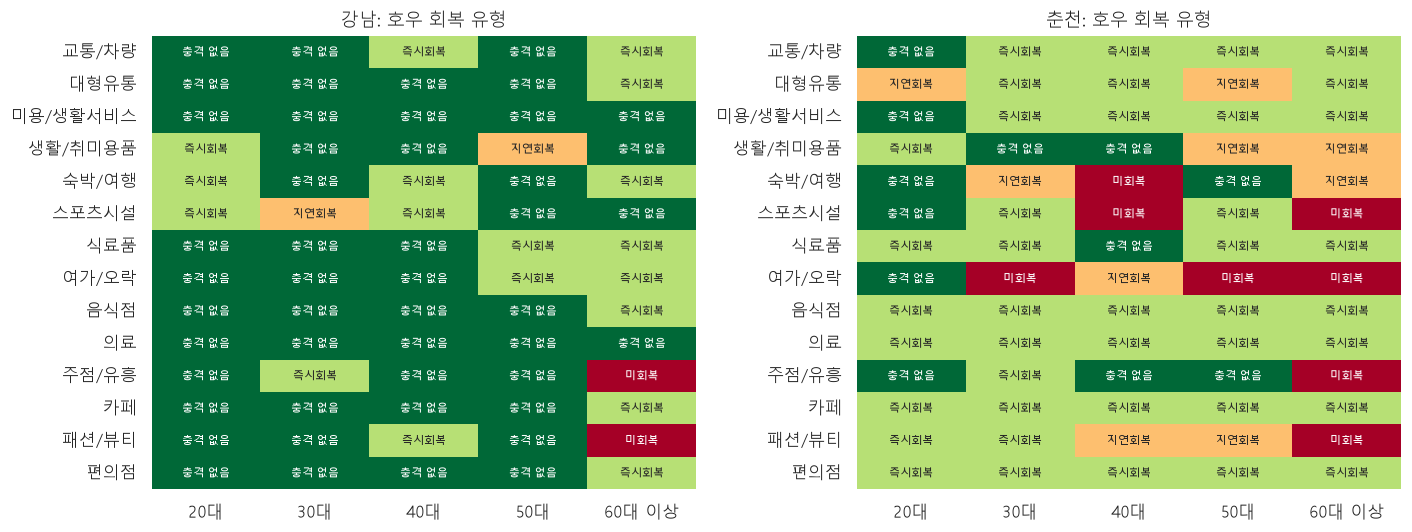

춘천 호우에서 지연회복 또는 미회복인 칸


구간,industry_group,age_g,pre,during,post1_3,post4_W,유형
0,대형유통,20대,-5.700,-64.900,-14.100,0.800,지연회복
1,대형유통,50대,-3.000,-29.900,-5.000,5.800,지연회복
2,생활/취미용품,50대,-0.400,-15.900,-8.400,-1.700,지연회복
3,생활/취미용품,60대 이상,-5.000,-18.700,-5.300,-2.600,지연회복
4,숙박/여행,30대,4.200,-9.600,-5.400,8.000,지연회복
5,숙박/여행,40대,-2.000,-11.300,-4.600,-8.800,미회복
6,숙박/여행,60대 이상,-8.000,-22.100,-12.300,-1.500,지연회복
7,스포츠시설,40대,-6.100,-36.700,-6.200,-6.600,미회복
8,스포츠시설,60대 이상,-11.300,-71.200,-8.300,-13.000,미회복
9,여가/오락,30대,-1.100,-22.900,-6.300,-3.400,미회복


In [20]:
구간정의 = {'pre': ('start', -7, -1), 'during': None, 'post1_3': ('end', 1, 3),
            'post4_W': ('end', 4, WINDOW[1]), 'post1_7': ('end', 1, 7)}
행 = []
for _, x in events.iterrows():
    for 이름, spec in 구간정의.items():
        lo, hi = ((x['start'], x['end']) if spec is None
                  else (x[spec[0]] + pd.Timedelta(days=spec[1]), x[spec[0]] + pd.Timedelta(days=spec[2])))
        for d in pd.date_range(lo, hi):
            행.append({'region': x['region'], 'event': x['event'], 'spell_id': x['spell_id'],
                       '구간': 이름, 'date': d})
ev_long = pd.DataFrame(행).merge(resid_ev, on=['date', 'region'])
구간열 = list(구간정의)
agg = (ev_long.groupby(['region', 'event', 'spell_id', 'industry_group', 'age_g', '구간'], observed=True)['resid']
       .mean().unstack('구간')
       .groupby(['region', 'event', 'industry_group', 'age_g'], observed=True)[구간열].mean().reset_index())


def 회복유형(r):
    B = RECOVERY_BAND
    if r['during'] > -B:
        return '충격 없음'
    if r['post1_3'] >= -B:
        return '즉시회복'
    if r['post4_W'] >= -B:
        return '지연회복'
    return '미회복'


agg['유형'] = agg.apply(회복유형, axis=1)
agg['이벤트'] = agg['event'].map(EV_NAME)
display(agg.groupby(['이벤트', 'region'])['유형'].value_counts().unstack(fill_value=0))

유형색 = {'충격 없음': 0, '즉시회복': 1, '지연회복': 2, '미회복': 3}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, REGIONS):
    t = agg[agg['region'].eq(r) & agg['event'].eq('rain30')]
    표 = t.pivot(index='industry_group', columns='age_g', values='유형')[MAIN_AGES]
    숫자 = 표.apply(lambda c: c.map(유형색)).astype(float)
    sns.heatmap(숫자, annot=표.values, fmt='', cmap='RdYlGn_r', vmin=0, vmax=3,
                ax=ax, cbar=False, annot_kws={'size': 7})
    ax.set(title=f'{r}: 호우 회복 유형', xlabel='', ylabel='')
plt.tight_layout(); plt.show()

print('춘천 호우에서 지연회복 또는 미회복인 칸')
display(agg[agg['region'].eq('춘천') & agg['event'].eq('rain30')
            & agg['유형'].isin(['지연회복', '미회복'])]
        .assign(**{c: lambda d, c=c: (d[c] * 100).round(1) for c in 구간열})
        [['industry_group', 'age_g', 'pre', 'during', 'post1_3', 'post4_W', '유형']]
        .reset_index(drop=True))

### 7장 정리
- **본 것**: 칸마다 평상일로만 학습한 기준선을 만들고, 호우 시작일 기준 궤적을 연령별, 업종그룹별로 그린 뒤 회복 유형을 붙였다.
- **나온 것**: 춘천 호우 당일 잔차가 20대 -6.8%에서 60대 이상 -16.4%로 깊어지고, **60대 이상만 +7일까지 음수에 머문다**(k=+7에서 -7.0%). 20 ~ 40대는 다음 날 0 근처로 돌아온다.
  회복 유형은 춘천 호우 70칸 중 즉시회복 41, 지연회복 9, 미회복 8, 충격 없음 12다. 지연회복과 미회복 17칸은 스포츠시설, 여가/오락, 숙박/여행, 패션/뷰티, 대형유통에 몰려 있고 **60대 이상이 6칸**으로 가장 많다.
- **시사점**: "춘천은 하루 만에 회복한다"(05번 7장)는 **평균의 이야기**다. 쪼개 보면 **고령층과 외지인 의존 업종은 하루 만에 안 돌아온다.**
  [추론] 다만 이 단위의 하루 흔들림이 22 ~ 41%라 60대 이상의 +7일 음수가 진짜 지연인지 소음인지는 이 표본으로 확정할 수 없다. 사건 수를 늘리거나(다른 해) 주 단위로 묶어 다시 봐야 한다.

## 8. 보조: 업종 67개 단위
업종그룹 대신 **업종 67개**로 내려가면 칸이 790개가 되고 0인 날이 9.84%로 늘어난다(74칸은 절반 이상이 0).
그래서 **1순위 업종그룹 안에서, 0인 날이 10% 미만인 칸만** 골라 보조로 확인한다.

### 8-1. 1순위 업종그룹 안에서

1순위 업종그룹 안의 칸 140개 중 0인 날 10% 미만인 칸 135개


회귀 135개, p < 0.05 35개, BH 통과 22개
호우에 가장 크게 빠지는 업종 x 연령 (BH 통과분)


,지역,업종그룹,업종,연령,호우(%),p,BH통과
0,춘천,식료품,농수산물,60대 이상,-26.100,0.000,True
1,강남,식료품,농수산물,30대,-23.610,0.000,True
2,강남,식료품,기타식품,50대,-18.810,0.010,True
3,춘천,카페,커피전문점,30대,-16.700,0.000,True
4,춘천,카페,커피전문점,50대,-16.060,0.000,True
5,춘천,카페,커피전문점,60대 이상,-14.460,0.000,True
6,춘천,카페,커피전문점,20대,-14.340,0.000,True
7,춘천,카페,커피전문점,40대,-14.250,0.000,True
8,춘천,식료품,기타식품,20대,-14.230,0.000,True
9,춘천,식료품,할인점/슈퍼마켓/양판점,60대 이상,-11.790,0.000,True


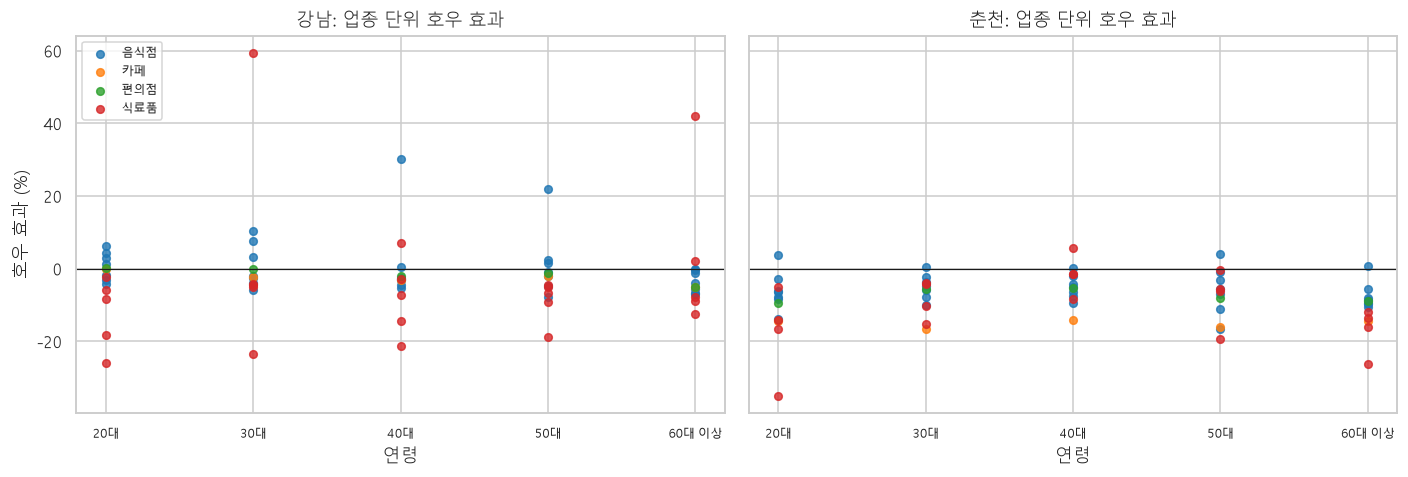

-> 업종그룹 안에서도 업종마다 흩어진다. 같은 카페 그룹이라도 업종에 따라 효과가 다르다.
-> 다만 칸이 작아 신뢰구간이 넓다. 이 장은 "그룹 결과가 특정 업종 하나 때문은 아닌지" 확인하는 용도다.


In [21]:
fine = add_wx_cal(
    base1[base1['age_g'].isin(MAIN_AGES) & base1['industry_group'].isin(PRIORITY_GROUPS)]
    .groupby(['date', 'region', 'industry_group', 'industry', 'age_g'], as_index=False, observed=True)
    .agg(amount=('amount', 'sum')))

빈날2 = (fine.assign(비었나=fine['amount'].eq(0))
         .groupby(['region', 'industry', 'age_g'], observed=True)['비었나'].mean())
쓸칸 = 빈날2[빈날2 < 0.10].index
print(f'1순위 업종그룹 안의 칸 {len(빈날2)}개 중 0인 날 10% 미만인 칸 {len(쓸칸)}개')

행 = []
for (r, g, i, a), q in fine.groupby(['region', 'industry_group', 'industry', 'age_g'], observed=True):
    if (r, i, a) not in 쓸칸:
        continue
    q = q[q['y'].notna()]
    m = smf.ols(WX_FORMULA, data=q).fit(cov_type='HC1')
    행.append({'지역': r, '업종그룹': g, '업종': i, '연령': a,
               '호우(%)': (np.exp(m.params['rain30[T.True]']) - 1) * 100,
               'p': m.pvalues['rain30[T.True]']})
fine_eff = pd.DataFrame(행)
fine_eff['BH통과'] = multipletests(fine_eff['p'], alpha=0.05, method='fdr_bh')[0]
print(f'회귀 {len(fine_eff)}개, p < 0.05 {int(fine_eff["p"].lt(0.05).sum())}개, BH 통과 {int(fine_eff["BH통과"].sum())}개')

print('호우에 가장 크게 빠지는 업종 x 연령 (BH 통과분)')
display(fine_eff[fine_eff['BH통과']].sort_values('호우(%)').head(15).round(2).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, r in zip(axes, REGIONS):
    t = fine_eff[fine_eff['지역'].eq(r)]
    for g, c in zip(PRIORITY_GROUPS, plt.cm.tab10.colors):
        s = t[t['업종그룹'].eq(g)]
        ax.scatter([MAIN_AGES.index(a) for a in s['연령']], s['호우(%)'],
                   color=c, label=g, s=25, alpha=0.8)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(range(len(MAIN_AGES))); ax.set_xticklabels(MAIN_AGES, fontsize=8)
    ax.set(title=f'{r}: 업종 단위 호우 효과', xlabel='연령')
axes[0].set_ylabel('호우 효과 (%)'); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('-> 업종그룹 안에서도 업종마다 흩어진다. 같은 카페 그룹이라도 업종에 따라 효과가 다르다.')
print('-> 다만 칸이 작아 신뢰구간이 넓다. 이 장은 "그룹 결과가 특정 업종 하나 때문은 아닌지" 확인하는 용도다.')

### 8장 정리
- **본 것**: 1순위 업종그룹(음식점, 카페, 편의점, 식료품) 안에서 업종 x 연령 칸 135개(0인 날 10% 미만)의 호우 효과를 다시 쟀다.
- **나온 것**: 135칸 중 **22칸이 BH를 통과**했다. 춘천 커피전문점은 20대부터 60대 이상까지 **다섯 연령 모두** -14 ~ -17%로 통과한다.
  가장 크게 빠지는 것은 춘천 농수산물 60대 이상 -26.1%, 강남 농수산물 30대 -23.6%다.
- **시사점**: 업종그룹 수준의 결론이 **특정 업종 하나 때문이 아니라 그룹 안의 여러 업종에 고르게 퍼져 있다.** 3장 히트맵의 춘천 호우 덩어리는 합치기 때문에 생긴 착시가 아니다.
  다만 업종 단위에서는 신뢰구간이 넓어 순위를 매기지는 않는다.

## 9. 뺀 10대만 따로 보기
1-3에서 뺀 10대를 여기서 따로 본다. **성긴 데이터를 억지로 같은 방법에 넣지 않고, 성긴 데이터에 맞는 질문으로 바꿔서** 묻는다.

| 칸의 상태 | 묻는 방법 |
|---|---|
| 0인 날이 10% 미만 (24칸) | 다른 장과 같은 로그 매출 회귀 |
| 0인 날이 10% 이상 (4칸) | 금액 대신 **"그날 결제가 있었나 없었나"(0/1)** 로 회귀 |
| 모든 업종그룹 합계 | 0이 없으므로 그냥 회귀. 10대 전체의 그림 |

### 9-1. 10대는 어떤 데이터인가

In [22]:
print(f'10대 금액 비중 {teen["amount"].sum() / cross["amount"].sum() * 100:.2f}%, '
      f'건수 비중 {teen["cnt"].sum() / cross["cnt"].sum() * 100:.2f}%')

빈날_10 = (teen.assign(비었나=teen['amount'].eq(0))
           .groupby(['region', 'industry_group'], observed=True)['비었나'].mean().mul(100))
display(빈날_10.unstack('region').sort_values('춘천', ascending=False).round(1)
        .rename_axis('10대: 0인 날 비중 (%)'))

# 10대가 어디에 돈을 쓰는가 (업종그룹 구성비)를 다른 연령과 비교
합계 = (cross.groupby(['age_g', 'industry_group'], observed=True)['amount']
        .sum().unstack('industry_group'))
구성 = 합계.div(합계.sum(axis=1), axis=0).mul(100).T[ALL_AGES]
display(구성.sort_values('10대', ascending=False).round(1).rename_axis('금액 구성비 (%)'))
print('-> 10대는 음식점, 편의점, 카페에 몰려 있다. 성긴 칸은 원래 10대가 거의 쓰지 않는 업종이다.')

10대 금액 비중 0.46%, 건수 비중 1.48%


region,강남,춘천
10대: 0인 날 비중 (%),,
주점/유흥,53.900,91.700
대형유통,0.000,54.900
숙박/여행,0.500,44.000
교통/차량,0.000,13.000
의료,0.000,5.400
미용/생활서비스,0.000,3.800
스포츠시설,0.000,1.100
패션/뷰티,0.000,0.500
생활/취미용품,0.000,0.000


age_g,10대,20대,30대,40대,50대,60대 이상
금액 구성비 (%),,,,,,
음식점,31.100,25.200,20.800,15.200,15.000,14.100
편의점,10.700,4.700,3.500,2.600,2.300,1.500
식료품,10.100,11.700,12.100,13.800,14.400,16.700
의료,8.600,22.600,25.300,28.400,29.900,34.100
생활/취미용품,7.900,5.200,4.600,4.800,5.100,4.500
카페,7.400,5.400,4.300,3.000,2.800,2.100
패션/뷰티,6.800,8.000,8.000,5.700,4.700,4.800
대형유통,5.900,7.700,12.500,17.700,16.100,12.800
여가/오락,4.600,1.100,0.500,0.500,0.500,0.200


-> 10대는 음식점, 편의점, 카페에 몰려 있다. 성긴 칸은 원래 10대가 거의 쓰지 않는 업종이다.


### 9-2. 쓸 수 있는 칸만 골라 효과 보기

0인 날 10% 미만인 칸 23개 / 전체 28개


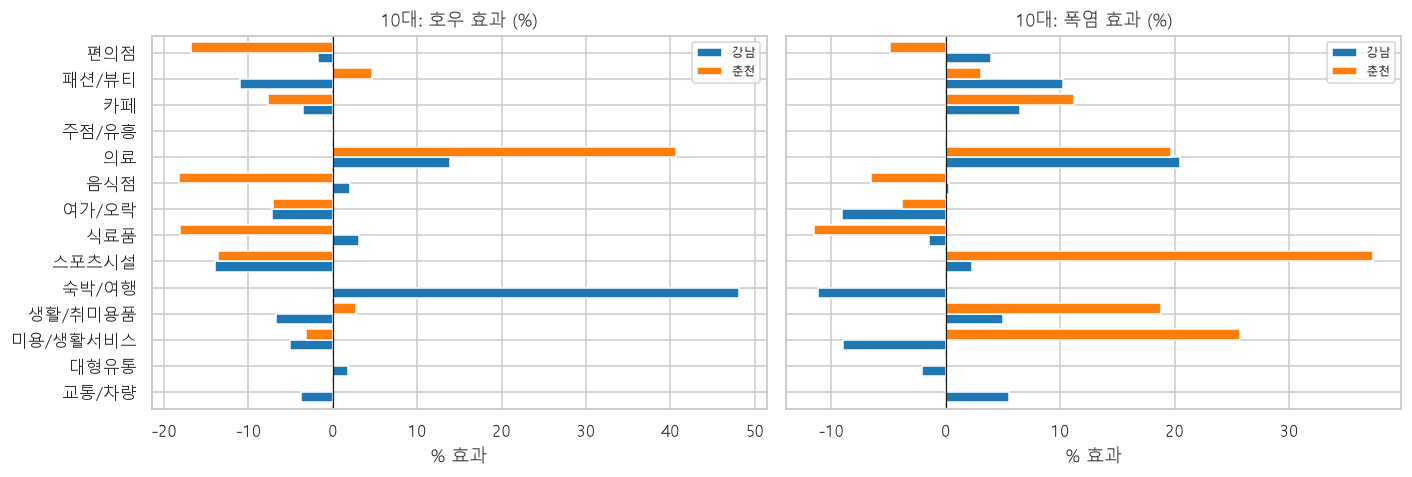

10대에서 p < 0.05 인 칸


,region,group,날씨,eff,lo,hi,p,BH통과
0,춘천,음식점,호우,-18.174,-26.641,-8.730,0.000,True
1,춘천,편의점,호우,-16.820,-23.550,-9.497,0.000,True
2,강남,카페,폭염,6.494,2.687,10.441,0.001,True


In [23]:
쓸수있는칸 = 빈날_10[빈날_10 < 10].index
print(f'0인 날 10% 미만인 칸 {len(쓸수있는칸)}개 / 전체 {len(빈날_10)}개')

행 = []
for (r, g), q in teen.groupby(['region', 'industry_group'], observed=True):
    if (r, g) not in 쓸수있는칸:
        continue
    q = q[q['y'].notna()]
    t = 효과뽑기(smf.ols(WX_FORMULA, data=q).fit(cov_type='HC1'))
    t.insert(0, 'group', g); t.insert(0, 'region', r)
    행.append(t)
teen_eff = pd.concat(행, ignore_index=True)
teen_eff['날씨'] = teen_eff['var'].map(WX_NAME)
for v in ['heat33', 'rain30']:
    s = teen_eff[teen_eff['var'].eq(v)]
    teen_eff.loc[s.index, 'BH통과'] = multipletests(s['p'], alpha=0.05, method='fdr_bh')[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, v in zip(axes, ['rain30', 'heat33']):
    s = teen_eff[teen_eff['var'].eq(v)]
    표 = s.pivot(index='group', columns='region', values='eff').reindex(GROUPS)
    표.plot.barh(ax=ax, color=[REGION_COLOR[c] for c in 표.columns], width=0.8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set(title=f'10대: {WX_NAME[v]} 효과 (%)', xlabel='% 효과', ylabel='')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('10대에서 p < 0.05 인 칸')
display(teen_eff[teen_eff['p'].lt(0.05) & teen_eff['var'].ne('tropical')]
        .sort_values('eff')[['region', 'group', '날씨', 'eff', 'lo', 'hi', 'p', 'BH통과']]
        .round(3).reset_index(drop=True))

### 9-3. 성긴 칸은 "결제가 있었나"로 바꿔 묻기
0인 날이 절반인 칸에서 "매출이 몇 % 줄었나"는 답할 수 없다. 대신 **"그날 결제가 한 건이라도 있었을 확률이 날씨에 따라 달라지나"** 는 답할 수 있다.
`있었나`(1/0)를 그대로 회귀하면 계수가 **확률 몇 %p** 로 읽힌다(선형확률모형).

In [24]:
teen = teen.copy()
teen['있었나'] = (teen['amount'] > 0).astype(int)
성긴칸 = 빈날_10[빈날_10 >= 10].index
print(f'성긴 칸 {len(성긴칸)}개: {list(성긴칸)}')

행 = []
for (r, g), q in teen.groupby(['region', 'industry_group'], observed=True):
    if (r, g) not in 성긴칸:
        continue
    m = smf.ols('있었나 ~ ' + CAL_FORMULA + ' + heat33 + tropical + rain30',
                data=q).fit(cov_type='HC1')
    행.append({'지역': r, '업종그룹': g, '결제가 있던 날(%)': q['있었나'].mean() * 100,
               '폭염(%p)': m.params['heat33[T.True]'] * 100, 'p폭염': m.pvalues['heat33[T.True]'],
               '호우(%p)': m.params['rain30[T.True]'] * 100, 'p호우': m.pvalues['rain30[T.True]']})
display(pd.DataFrame(행).set_index(['지역', '업종그룹']).round(2))

# 10대 전체(업종그룹 합계)는 0이 없으므로 그냥 회귀한다
teen_total = add_wx_cal(base1[base1['age_g'].eq('10대')]
                        .groupby(['date', 'region'], as_index=False, observed=True)
                        .agg(amount=('amount', 'sum'), cnt=('cnt', 'sum')))
행 = []
for r in REGIONS:
    t = 효과뽑기(smf.ols(WX_FORMULA, data=teen_total[teen_total['region'].eq(r)]).fit(cov_type='HC1'))
    t.insert(0, '지역', r)
    행.append(t)
t = pd.concat(행, ignore_index=True)
t['날씨'] = t['var'].map(WX_NAME)
print('10대 전체 (업종그룹 합계)')
display(t.pivot(index='날씨', columns='지역', values='eff').round(1))
display(t.pivot(index='날씨', columns='지역', values='p').round(3).rename_axis('p값'))

# 다른 연령과 나란히 놓기
비교 = 연령효과[연령효과['var'].eq('rain30')][['region', 'age', 'eff']].copy()
비교 = pd.concat([비교, t[t['var'].eq('rain30')].rename(columns={'지역': 'region'}).assign(age='10대')
                 [['region', 'age', 'eff']]])
display(비교.pivot(index='age', columns='region', values='eff').reindex(ALL_AGES).round(1)
        .rename_axis('호우 효과 (%, 지역 합계)'))

성긴 칸 5개: [('강남', '주점/유흥'), ('춘천', '교통/차량'), ('춘천', '대형유통'), ('춘천', '숙박/여행'), ('춘천', '주점/유흥')]


결제가 있던 날(%)  폭염(%p)   p폭염  호우(%p)   p호우
지역 업종그룹                                          
강남 주점/유흥       46.070  -3.580 0.800  18.520 0.290
춘천 교통/차량       86.960   0.790 0.950 -19.170 0.100
   대형유통        45.050  -6.980 0.450  -9.310 0.410
   숙박/여행       55.980  -0.650 0.960  -4.250 0.720
   주점/유흥        8.280  -9.520 0.390  -5.620 0.440

10대 전체 (업종그룹 합계)


지역,강남,춘천
날씨,,
열대야,1.500,10.400
폭염,5.300,-2.600
호우,-2.900,-14.100


지역,강남,춘천
p값,,
열대야,0.741,0.180
폭염,0.159,0.598
호우,0.466,0.006


region,강남,춘천
"호우 효과 (%, 지역 합계)",,
10대,-2.900,-14.100
20대,0.900,-5.600
30대,2.200,-5.700
40대,-1.200,-5.600
50대,-2.600,-10.700
60대 이상,-1.400,-12.700


### 9장 정리
- **본 것**: 10대만 따로, 칸 상태에 따라 세 가지 방법(로그 매출 회귀 23칸 / 결제 발생 0-1 회귀 5칸 / 전체 합계 회귀)으로 물었다.
- **나온 것**: 10대는 금액의 0.46%지만 **음식점 31.1%, 편의점 10.7%, 카페 7.4%** 로 쓰는 곳이 뚜렷해서 이 업종들에서는 칸이 충분하다(편의점 비중은 60대 이상의 7배다).
  춘천 호우일에 음식점 **-18.2%**, 편의점 **-16.8%** 로 다른 어느 연령보다 크게 빠진다. 강남 카페는 폭염일 +6.5%다(셋 다 BH 통과).
  성긴 칸 5개는 "결제가 있을 확률" 자체가 날씨와 뚜렷한 관계를 보이지 않는다(p 0.10 ~ 0.96).
- **시사점**: **10대를 뺀 것은 옳았지만 10대에 신호가 없어서는 아니다.** 오히려 지역 합계로 보면 춘천 호우 효과가 10대 -14.1%(p 0.006)로 **모든 연령 중 가장 크다.**
  연령별로 -14.1(10대), -5.6, -5.7, -5.6, -10.7, -12.7(60대 이상)이라 **U자 모양**이다. 가운데(20 ~ 40대)가 가장 덜 빠지고 양 끝이 크게 빠진다.
  [추론] 차를 쓰지 않고 걷거나 대중교통으로 움직이는 연령대가 양 끝이라는 설명이 자연스럽지만, 이 데이터에는 이동 수단이 없어 확인할 수 없다.
  보고서에 10대 숫자를 쓸 때는 **금액 비중이 0.46%** 라는 점을 반드시 함께 적는다.

## 10. 전체 정리

### 10-1. 핵심 결과표

In [25]:
t = eff[eff['var'].eq('rain30')].copy()
t['표시'] = [f'{e:+.0f}' + ('*' if q else ('.' if p < 0.05 else ''))
            for e, p, q in zip(t['eff'], t['p'], t['BH통과'])]
핵심 = t.pivot(index=['region', 'group'], columns='age', values='표시')[MAIN_AGES]
display(핵심.rename_axis(['지역', '업종그룹']))
print('* = BH 통과(가짜일 확률 5% 이하), . = p < 0.05 지만 BH 탈락(우연일 수 있음), 빈칸 = 효과 없음')

# 연령 차이가 유의한 조합만 따로
print('4장에서 연령 차이가 유의했던 조합')
display(inter[inter['연령차이 있음']].sort_values(['날씨', 'p'])
        [['날씨', '지역', '업종그룹', 'F', 'p']].round(4).reset_index(drop=True))

age           20대   30대   40대   50대 60대 이상
지역 업종그룹                                   
강남 교통/차량       +5    +0    -5    +0     -8
   대형유통        -2    -0    +0    -3     -4
   미용/생활서비스    +6    +1    -3    +2     -1
   생활/취미용품    -10    +5    -2    -7     +8
   숙박/여행       -8   +22   -16   +17     -7
   스포츠시설       -7    -2    -4    +0    +10
   식료품         -3    -4    -4    -6    -8.
   여가/오락       +3    -3    +2    -4     -2
   음식점         +0    +1    +1    -0     -4
   의료          +5    -1    +3    -1     +4
   주점/유흥      +35   +13   +23    +6    +11
   카페          -0    -2    -3    -2    -5*
   패션/뷰티       +7  +23*    -4   +19     -1
   편의점         +0    +0    -2    -1    -5*
춘천 교통/차량       -2   -9*  -12*  -15*    -9.
   대형유통       -41   -10   -15  -31.   -18.
   미용/생활서비스    -3    -6    -8    -3     -8
   생활/취미용품    -10    +2    +3  -13.   -19*
   숙박/여행      +19    -8    -9    +3   -21.
   스포츠시설       -2   -12  -30*  -43*   -53*
   식료품        -9.    -5    -1   -6.   -14*
   여가/오락       -0   -16  -21.    -7    -14
   음식점        -7*    -5    -5   -6*    -9*
   의료          -0    -2    -3    -9     -3
   주점/유흥      +21   -12    +7    +3     -6
   카페        -14*  -17*  -14*  -16*   -14*
   패션/뷰티       -9   -11    -9   -12   -22*
   편의점       -10*   -6*   -5.   -8*    -9*

* = BH 통과(가짜일 확률 5% 이하), . = p < 0.05 지만 BH 탈락(우연일 수 있음), 빈칸 = 효과 없음
4장에서 연령 차이가 유의했던 조합


,날씨,지역,업종그룹,F,p
0,폭염,춘천,편의점,42.008,0.000
1,폭염,춘천,음식점,14.579,0.000
2,폭염,강남,생활/취미용품,6.075,0.000
3,폭염,강남,식료품,4.416,0.002
4,폭염,춘천,카페,3.861,0.005
5,폭염,강남,음식점,3.447,0.010
6,폭염,강남,미용/생활서비스,3.354,0.011
7,폭염,강남,카페,3.105,0.017
8,폭염,춘천,스포츠시설,3.002,0.020
9,폭염,강남,여가/오락,2.441,0.049


### 10-2. 보고서에 넣을 그림

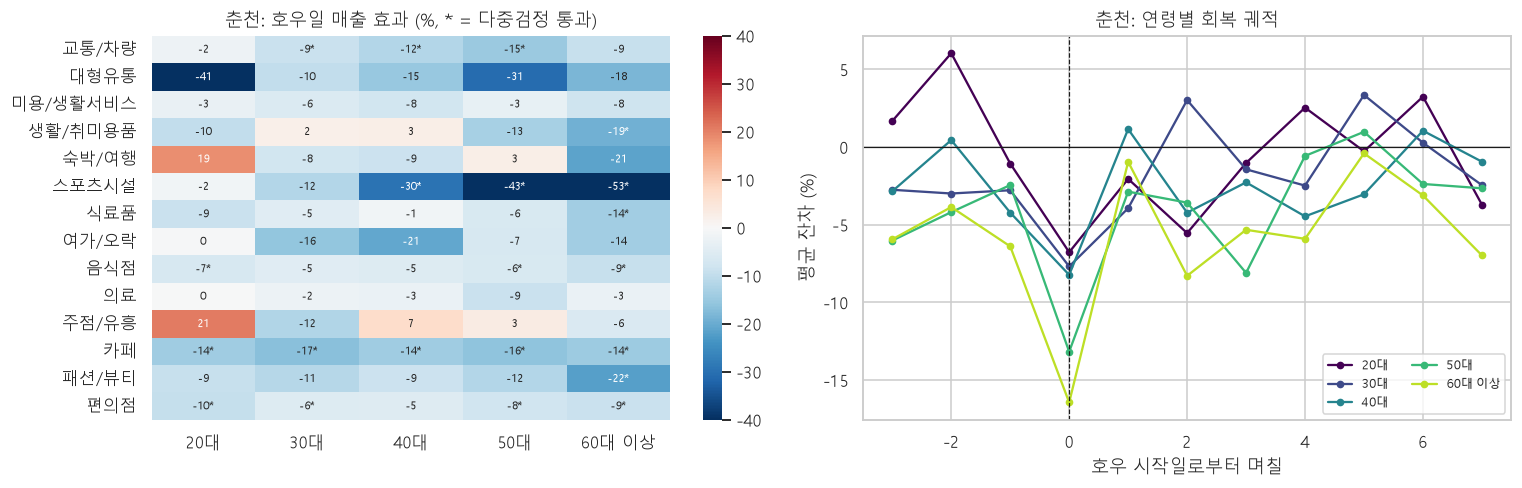

-> 왼쪽은 "얼마나 빠지는가", 오른쪽은 "언제 돌아오는가". 두 장이 이 노트북의 결론이다.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

# 왼쪽: 춘천 호우 효과 히트맵
s = eff[eff['var'].eq('rain30') & eff['region'].eq('춘천')]
값 = s.pivot(index='group', columns='age', values='eff')[MAIN_AGES]
별 = s.pivot(index='group', columns='age', values='BH통과')[MAIN_AGES]
라벨 = 값.round(0).astype(int).astype(str) + np.where(별, '*', '')
sns.heatmap(값, annot=라벨, fmt='', cmap='RdBu_r', center=0, vmin=-40, vmax=40,
            ax=axes[0], cbar=True, annot_kws={'size': 7})
axes[0].set(title='춘천: 호우일 매출 효과 (%, * = 다중검정 통과)', xlabel='', ylabel='')

# 오른쪽: 춘천 연령별 회복 궤적
색 = plt.cm.viridis(np.linspace(0, 0.9, len(MAIN_AGES)))
for c, a in zip(색, MAIN_AGES):
    g = rain_traj[rain_traj['region'].eq('춘천') & rain_traj['age_g'].eq(a)].sort_values('k')
    axes[1].plot(g['k'], g['mean'], 'o-', color=c, ms=4, label=a)
axes[1].axhline(0, color='k', lw=0.8); axes[1].axvline(0, ls='--', color='k', lw=0.8)
axes[1].set(xlabel='호우 시작일로부터 며칠', ylabel='평균 잔차 (%)',
            title='춘천: 연령별 회복 궤적')
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()
print('-> 왼쪽은 "얼마나 빠지는가", 오른쪽은 "언제 돌아오는가". 두 장이 이 노트북의 결론이다.')

### 10-3. 한계
- **다중검정**: 칸 140개를 각각 검정하면 효과가 없어도 7칸은 우연히 유의하다. 이 노트북은 BH 보정과 4장의 상호작용 검정을 함께 써서 걸렀지만, **보정을 통과하지 못한 칸의 숫자를 인용하면 안 된다.**
- **소음이 커졌다**: 업종그룹 x 연령 칸의 평상일 하루 흔들림은 22 ~ 41%로, 05번의 업종그룹 단위(7 ~ 9%)보다 훨씬 크다. 회복 유형 판정 폭(0.03)은 05번과 맞췄지만 **이 단위에서는 상대적으로 좁다.**
- **사건 수가 적다**: 호우 구간이 강남 8개, 춘천 14개뿐이다. 연령까지 쪼개면 한 칸의 궤적이 사건 14개 평균이라, 사건 하나가 빠지면 값이 눈에 띄게 움직인다.
- **폭염 창이 겹친다**: 05번 6-2와 같은 한계다. 폭염 이벤트 궤적은 참고로만 본다.
- **연령은 결제자 기준이다**: 가족 카드, 대리 결제는 구분되지 않는다. 특히 10대와 60대 이상에서 실제 소비자와 결제자가 다를 수 있다.
- **절대 금액은 쓰지 않았다**: 08번에서 확인한 배수 문제 때문이다. 이 노트북의 모든 숫자는 % 효과와 비중이다.
- **지역이 2개뿐**: 연령 기울기가 춘천에만 있다는 것은 "도시 구조 차이"로 보이지만, 지역 2개로는 검정할 수 없다.